# Relatório Consolidado de Projeto: Detecção de Fraude em Cartão de Crédito

--- 

## 1. Introdução e Análise Exploratória de Dados (EDA)

O objetivo deste projeto é desenvolver um modelo de machine learning altamente robusto para identificar transações fraudulentas de cartão de crédito, minimizando tanto as perdas financeiras quanto os falsos alarmes que afetam a experiência do cliente.

### 1.1. Perfil da Base de Dados
A base possui **284.807 transações**, das quais apenas **492 são fraudes**. Isso representa um desbalanceamento extremo de **0,17% de fraudes** contra **99,83% de transações legítimas**.

### 1.2. Comportamento das Variáveis
* **`Amount` (Valor da Transação):** 
  * A mediana geral das transações legítimas é relativamente baixa ~22. No entanto, o valor maximo alcanca 25.691,16, mostrando uma cauda extremamente longa para a direita.
  * As transações fraudulentas apresentam distribuições de valores mais dispersas e concentradas em tíquetes médios moderados, mas com alto impacto acumulado.
* **Correlações e Componentes Principais (PCA):** 
  * As variáveis de $V_1$ a $V_{28}$ são o resultado de uma transformação por Análise de Componentes Principais (PCA), garantindo correlação linear nula entre si.
  * Identificamos variáveis de **Alto Impacto** com excelente separação de médias e distribuições distintas para fraudes (ex: `V14`, `V12`, `V17`) contra variáveis de **Baixo Impacto** com alta sobreposição (ex: `V22`, `V25`, `V26`).

--- 

## 2. Estratégias de Balanceamento de Dados

Para lidar com o severo desbalanceamento de classes, três abordagens de baseline foram avaliadas utilizando Regressão Logística como classificador de referência:

1. **Ajuste de Pesos de Classe (`class_weight='balanced'`):** Penaliza de forma proporcional os erros da classe minoritária sem alterar fisicamente a base.
2. **Under-sampling Operacional (1:1):** Reduz drasticamente a classe legítima de treino, limitando-a à quantidade de fraudes.
3. **Over-sampling Sintético (SMOTE):** Cria novos vetores sintéticos de fraude com base nos vizinhos mais próximos.

### Tabela Comparativa de Performance (Métricas na Classe 1 - Fraude):

| Técnica | Precisão (Fraude) | Recall (Sensibilidade) | F1-Score | Alarmes Falsos (FP) | Fraudes Detectadas (TP) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Ajuste de Pesos** | 6,00% | 87,16% | 12,00% | 1.886 | 129 de 148 |
| **Under-sampling (1:1)** | 6,00% | 87,84% | 11,00% | 2.043 | 130 de 148 |
| **Over-sampling (SMOTE)** | 6,00% | 87,84% | 12,00% | 1.965 | 130 de 148 |

* **Conclusão:** O **SMOTE** e o Ajuste de Pesos mostraram-se os mais promissores para alimentar modelos mais complexos, pois o subamostramento descarta informações contextuais valiosas das transações legítimas.

--- 

## 3. Comparativo de Algoritmos de Machine Learning

Avaliou-se a performance de algoritmos avançados lineares e de árvores utilizando a **Área sob a Curva Precision-Recall (AUPRC)** como métrica de sucesso principal:

* **Regressão Logística (Baseline):** AUPRC = **0,7391**
* **CatBoost Classifier (Weighted):** AUPRC = **0,8061**
* **Random Forest (Balanced):** AUPRC = **0,8279**
* **XGBoost Classifier (Weighted):** AUPRC = **0,8360** (Vencedor inicial)

--- 

## 4. Engenharia de Recursos e Seleção de Variáveis (*Forward Selection*)

Para otimizar o custo de processamento operacional, latência de inferência em tempo real e evitar overfitting, avaliamos o impacto do número de variáveis na performance do XGBoost:

* Começando pela mais explicativa (`V14`) e adicionando progressivamente variáveis de acordo com a importância estatística, identificamos um **platô claro de performance com 15 variáveis**.
* O modelo reduzido com 15 variáveis apresentou um **AUPRC de 0,8426** (um ganho marginal de performance em relação às 29 variáveis, provando que a simplificação removeu ruídos analíticos).
* **As 15 variáveis selecionadas foram:** `V14`, `V4`, `V12`, `V10`, `V13`, `V7`, `V11`, `Amount`, `V27`, `V17`, `V26`, `V21`, `V23`, `V3`, `V18`.

--- 

## 5. Ajuste Fino de Hiperparâmetros com Optuna (O Modelo de Produção)

Utilizamos o framework **Optuna** com validação cruzada estratificada sobre a base tratada por SMOTE, executando 30 trials de otimização focados em maximizar a capacidade de generalização (AUC e AUPRC) e controlar o sobreajuste.

### Escolha de Produção: **Trial 6**
O **Trial 6** se destacou como o mais equilibrado para produção devido à excelente taxa de generalização (Diferença entre Treino e Teste de apenas **0,0284** e AUC de teste de **0,9711**):

* **Parâmetros Finais (Trial 6):**
  * `n_estimators`: 287
  * `learning_rate`: 0.012015
  * `max_depth`: 6
  * `subsample`: 0.7292
  * `colsample_bytree`: 0.7227
  * `min_child_weight`: 7
  * `reg_alpha`: 0.001197
  * `reg_lambda`: 0.006281

*O arquivo de produção foi exportado e salvo com sucesso em disk como: `xgb_fraud_detector_trial_6.pkl`.*

--- 

## 6. Análise de Erros: Por que o modelo erra (Falsos Negativos)?

Investigamos as **33 fraudes** que o modelo final de classificação binária padrão não conseguiu detectar (Falsos Negativos):
* **V14 (Variável Crítica):** Nas fraudes detectadas, o valor médio de `V14` é de **-7,77**. Nas fraudes não detectadas (FN), a média de `V14` é de **-0,30**, o que as assemelha quase perfeitamente às transações legítimas (cuja média é de **0,00**).
* **Comportamento Mimético:** Os criminosos desses casos usaram técnicas para mimetizar o comportamento de clientes comuns nas variáveis transacionais rastreadas.
* **Mitigação Operacional:** Como resolver? Através da **Ordenação por Score (Probabilidade)** descrita na seção a seguir.

--- 

## 7. Análise de Risco e Resultados de Negócio (Métricas $P_1$, $P_5$ e $P_{10}$)

Em um cenário de prevenção de fraudes, o modelo não deve ser usado apenas de forma binária (Sim/Não). Deve-se ordenar as transações do maior para o menor score de probabilidade e focar a equipe operacional nas transações de maior risco.

Ao ordenar as **85.443 transações do conjunto de teste**, obtivemos os seguintes resultados operacionais:

### Tabela de Concentração de Risco:

| % da Base Inspecionada (Risco) | Vol. Transações Inspecionadas | Fraudes Reais Detectadas | Precisão ($P_x$) | Recall Acumulado (Captura) |
| :---: | :---: | :---: | :---: | :---: |
| **Top 1% ($P_1$)** | 854 transações | **127** | **14,87%** | **85,81%** |
| **Top 5% ($P_5$)** | 4.272 transações | **134** | 3,14% | **90,54%** |
| **Top 10% ($P_{10}$)** | 8.544 transações | **136** | 1,59% | **91,89%** |

* **A taxa natural de fraude na base é de apenas 0,17%**.
* Ao inspecionar o **Top 1%** de maior risco fornecido pelo modelo, a equipe de fraudes encontrará uma taxa de conversão de **14,87% de fraudes reais** (um aumento de **87x** a eficiência de detecção!).
* Inspecionando ou revisando apenas **5% das transações mais arriscadas**, a operação captura **90,54% de toda a perda financeira** por fraude.
* **Recuperação de Falsos Negativos:** Das 33 fraudes perdidas no corte rígido binário padrão, **21 fraudes** estão presentes dentro da faixa de risco do Top 10%, mostrando que a ordenação por score é a forma mais eficaz e segura de operar o modelo.

--- 

## 8. Recomendação e Workflow de Implantação sugerido

1. **Ação Automática (Top 1% - Altíssimo Risco):** Bloqueio instantâneo da transação com disparo de desafio por biometria facial ou token no app do cliente. (Captura 85,8% das fraudes com baixíssimo impacto no volume geral).
2. **Revisão Manual (Top 1% ao Top 5% - Médio/Alto Risco):** Encaminhamento para a mesa de análise humana interna antes da liberação final do crédito.
3. **Aprovação Automática (Abaixo do Top 10% - Baixíssimo Risco):** Transações aprovadas de forma transparente sem fricção na experiência de compra.

## 00. Carregando base 

In [1]:
import pandas as pd

# Ler o arquivo CSV passando o nome correto como texto (entre aspas)
df = pd.read_csv("creditcard.csv")

# Exibir as primeiras 5 linhas
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Descritiva 

In [2]:
import pandas as pd

# 1. Atribui a sua base já existente para a variável 'df'

# 2. Exibir as primeiras 5 linhas do dataset
print("--- Primeiras Linhas ---")
display(df.head())

# 3. Informações gerais sobre os tipos de dados e valores ausentes
print("\n--- Informações Gerais do DataFrame ---")
df.info()

# 4. Resumo estatístico das colunas numéricas
print("\n--- Resumo Estatístico ---")
display(df.describe())

# 5. Distribuição da classe alvo (Class: 0 = Normal, 1 = Fraude)
print("\n--- Distribuição da Variável Target (Class) ---")
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

for val, count in class_counts.items():
    label = "Normal (0)" if val == 0 else "Fraude (1)"
    print(f"Classe {val} [{label}]: {count:,} registros ({class_percentages[val]:.4f}%)")

--- Primeiras Linhas ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Informações Gerais do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20    

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



--- Distribuição da Variável Target (Class) ---
Classe 0 [Normal (0)]: 284,315 registros (99.8273%)
Classe 1 [Fraude (1)]: 492 registros (0.1727%)


### 1.1 Comportamento das Variáveis

--- Estatísticas Descritivas de 'Amount' ---
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
90%         203.000000
95%         365.000000
99%        1017.970000
max       25691.160000
Name: Amount, dtype: float64

--- Média e Mediana de 'Amount' por Classe (0 = Normal, 1 = Fraude) ---


,mean,median,std,max,count
Class,,,,,
0,88.291022,22.00,250.105092,25691.16,284315
1,122.211321,9.25,256.683288,2125.87,492


/tmp/ipykernel_3841/13926422.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Normal (0)', 'Fraude (1)'])


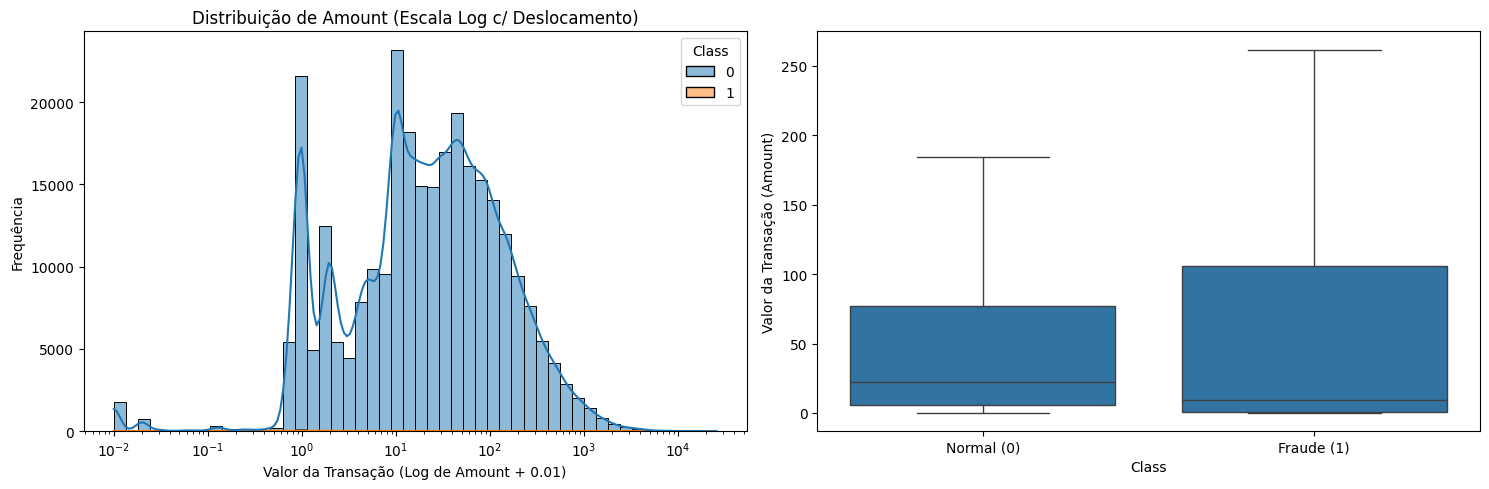

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Resumo Estatístico Detalhado da coluna Amount
print("--- Estatísticas Descritivas de 'Amount' ---")
amount_stats = df['Amount'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(amount_stats)

# 2. Comparação de valores de transações entre transações Normais e Fraudes
print("\n--- Média e Mediana de 'Amount' por Classe (0 = Normal, 1 = Fraude) ---")
grouped_stats = df.groupby('Class')['Amount'].agg(['mean', 'median', 'std', 'max', 'count'])
display(grouped_stats)

# 3. Visualização Gráfica da Distribuição
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Correção do erro de log: criamos uma coluna temporária somando 0.01 para evitar log(0)
df_temp = df.copy()
df_temp['Amount_Log_Safe'] = df_temp['Amount'] + 0.01

# Histograma usando a coluna segura contra valores zero
sns.histplot(data=df_temp, x='Amount_Log_Safe', hue='Class', bins=50, kde=True, ax=axes[0], log_scale=(True, False))
axes[0].set_title('Distribuição de Amount (Escala Log c/ Deslocamento)')
axes[0].set_xlabel('Valor da Transação (Log de Amount + 0.01)')
axes[0].set_ylabel('Frequência')

# Boxplot comparando as classes (limitando o eixo Y para melhor visualização)
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1], showfliers=False)
axes[1].set_xticklabels(['Normal (0)', 'Fraude (1)'])
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Valor da Transação (Amount)')

plt.tight_layout()
plt.show()

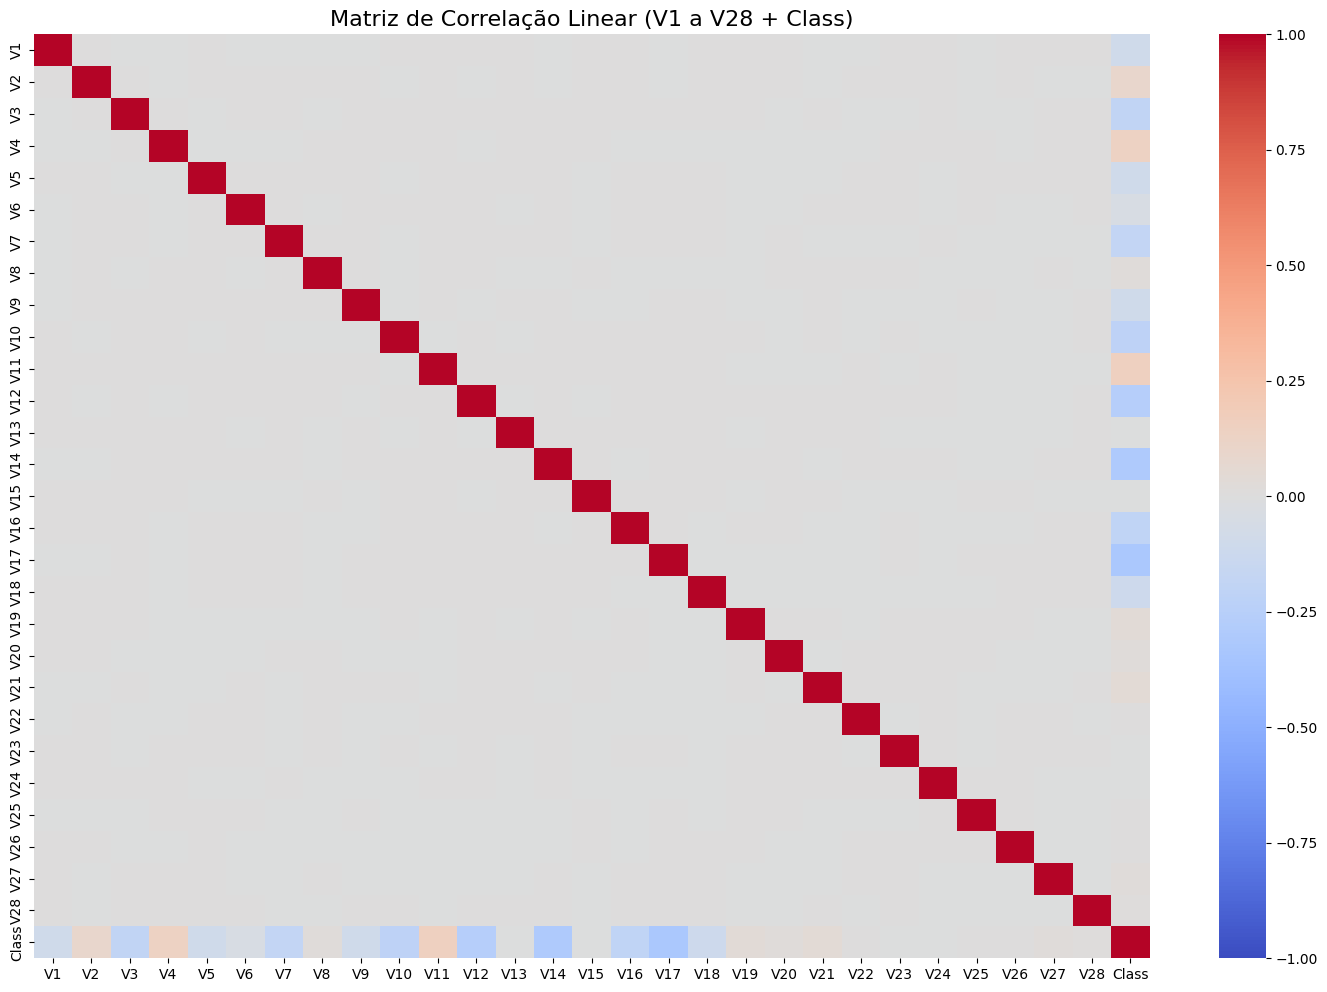

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular a matriz de correlação apenas para as variáveis V1 a V28 e Class
v_cols = [f'V{i}' for i in range(1, 29)]
cols_to_corr = v_cols + ['Class']
corr_matrix = df[cols_to_corr].corr()

# 2. Gerar o Heatmap de Correlação
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear (V1 a V28 + Class)', fontsize=16)
plt.show()

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_iv_continuous(df, feature, target, num_bins=10):
    """
    Calcula o Information Value (IV) para uma variável contínua dividindo-a em quantis.
    """
    # Criar faixas (bins) de valores
    df_temp = pd.DataFrame({'feature': df[feature], 'target': df[target]})
    try:
        df_temp['bin'] = pd.qcut(df_temp['feature'], q=num_bins, duplicates='drop')
    except ValueError:
        # Caso falhe a divisão por quantis idênticos, divide por intervalos de mesmo tamanho
        df_temp['bin'] = pd.cut(df_temp['feature'], bins=num_bins)

    # Agrupar e calcular estatísticas de bons (Legítimas) e maus (Fraudes)
    grouped = df_temp.groupby('bin', observed=False)['target'].agg(['count', 'sum'])
    grouped.columns = ['Total', 'Fraude']
    grouped['Legitima'] = grouped['Total'] - grouped['Fraude']

    # Proporções de distribuição de cada evento
    total_fraude = grouped['Fraude'].sum()
    total_legitima = grouped['Legitima'].sum()

    grouped['Prop_Fraude'] = grouped['Fraude'] / total_fraude
    grouped['Prop_Legitima'] = grouped['Legitima'] / total_legitima

    # Substituir proporções nulas para evitar divisão por zero ou log de zero
    grouped['Prop_Fraude'] = grouped['Prop_Fraude'].replace(0, 0.0001)
    grouped['Prop_Legitima'] = grouped['Prop_Legitima'].replace(0, 0.0001)

    # Calcular WoE (Weight of Evidence) e IV individual
    grouped['WoE'] = np.log(grouped['Prop_Legitima'] / grouped['Prop_Fraude'])
    grouped['IV_bin'] = (grouped['Prop_Legitima'] - grouped['Prop_Fraude']) * grouped['WoE']

    iv = grouped['IV_bin'].sum()
    return iv

# Calcular o IV para as 28 componentes principais
iv_results = {}
for col in v_cols:
    iv_results[col] = calculate_iv_continuous(df, col, 'Class', num_bins=10)

# Converter em DataFrame e categorizar a força preditiva
iv_df = pd.DataFrame.from_dict(iv_results, orient='index', columns=['Information_Value']).sort_values(by='Information_Value', ascending=False)

def classificar_iv(iv):
    if iv < 0.02: return 'Inútil (< 0.02)'
    elif iv < 0.1: return 'Fraco (0.02 - 0.1)'
    elif iv < 0.3: return 'Médio (0.1 - 0.3)'
    elif iv < 0.5: return 'Forte (0.3 - 0.5)'
    else: return 'Muito Forte (> 0.5)'

iv_df['Forca_Preditiva'] = iv_df['Information_Value'].apply(classificar_iv)

print("--- Top 5 Variáveis com Maior Information Value (IV) ---")
display(iv_df.head(5))

print("\n--- Top 5 Variáveis com Menor Information Value (IV) ---")
display(iv_df.tail(5))

--- Top 5 Variáveis com Maior Information Value (IV) ---


,Information_Value,Forca_Preditiva
V4,3.832981,Muito Forte (> 0.5)
V14,3.780017,Muito Forte (> 0.5)
V12,3.210878,Muito Forte (> 0.5)
V17,3.052115,Muito Forte (> 0.5)
V10,2.967957,Muito Forte (> 0.5)



--- Top 5 Variáveis com Menor Information Value (IV) ---


,Information_Value,Forca_Preditiva
V24,0.153777,Médio (0.1 - 0.3)
V25,0.108044,Médio (0.1 - 0.3)
V13,0.073025,Fraco (0.02 - 0.1)
V15,0.064872,Fraco (0.02 - 0.1)
V22,0.047807,Fraco (0.02 - 0.1)


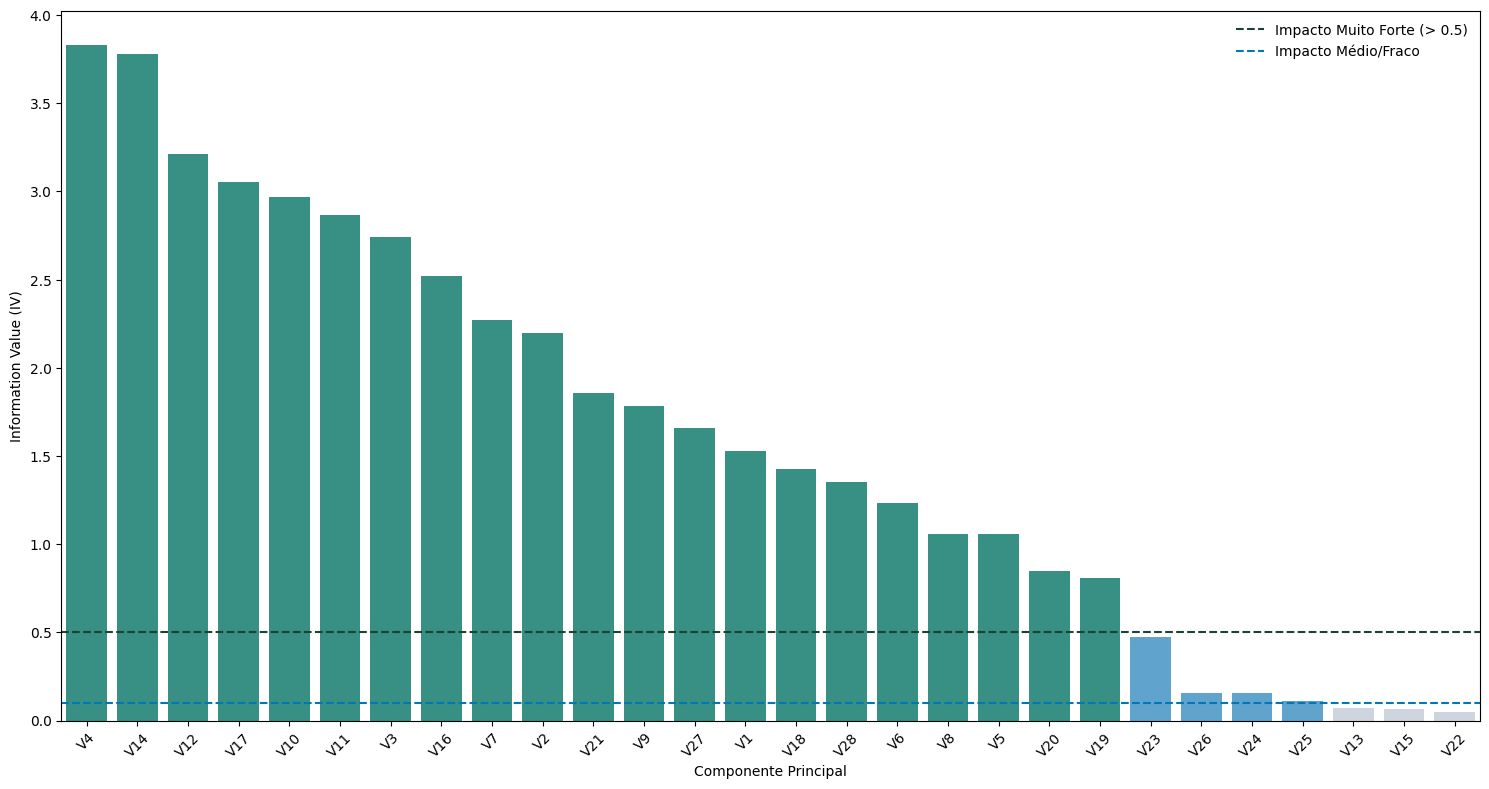

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

# Cores suaves em tons de verde, azul e cinza azulado
# Verde Teal (#2a9d8f) -> Impacto Muito Forte (> 0.5)
# Azul Soft (#4ea8de) -> Impacto Médio/Fraco (> 0.1)
# Cinza Muted (#cbd5e1) -> Impacto Irrelevante (<= 0.1)
colors = iv_df['Information_Value'].apply(
    lambda x: '#2a9d8f' if x > 0.5 else ('#4ea8de' if x > 0.1 else '#cbd5e1')
)

# Plotagem do gráfico de barras (sem avisos)
sns.barplot(
    x=iv_df.index, 
    y=iv_df['Information_Value'], 
    hue=iv_df.index, 
    palette=colors.tolist(), 
    legend=False
)

# Linhas de limiar com tons combinando e estilo elegante
plt.axhline(
    y=0.5, color='#1b4332', linestyle='--', linewidth=1.5, 
    label='Impacto Muito Forte (> 0.5)'
)
plt.axhline(
    y=0.1, color='#0077b6', linestyle='--', linewidth=1.5, 
    label='Impacto Médio/Fraco'
)

plt.xlabel('Componente Principal')
plt.ylabel('Information Value (IV)')
plt.xticks(rotation=45)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

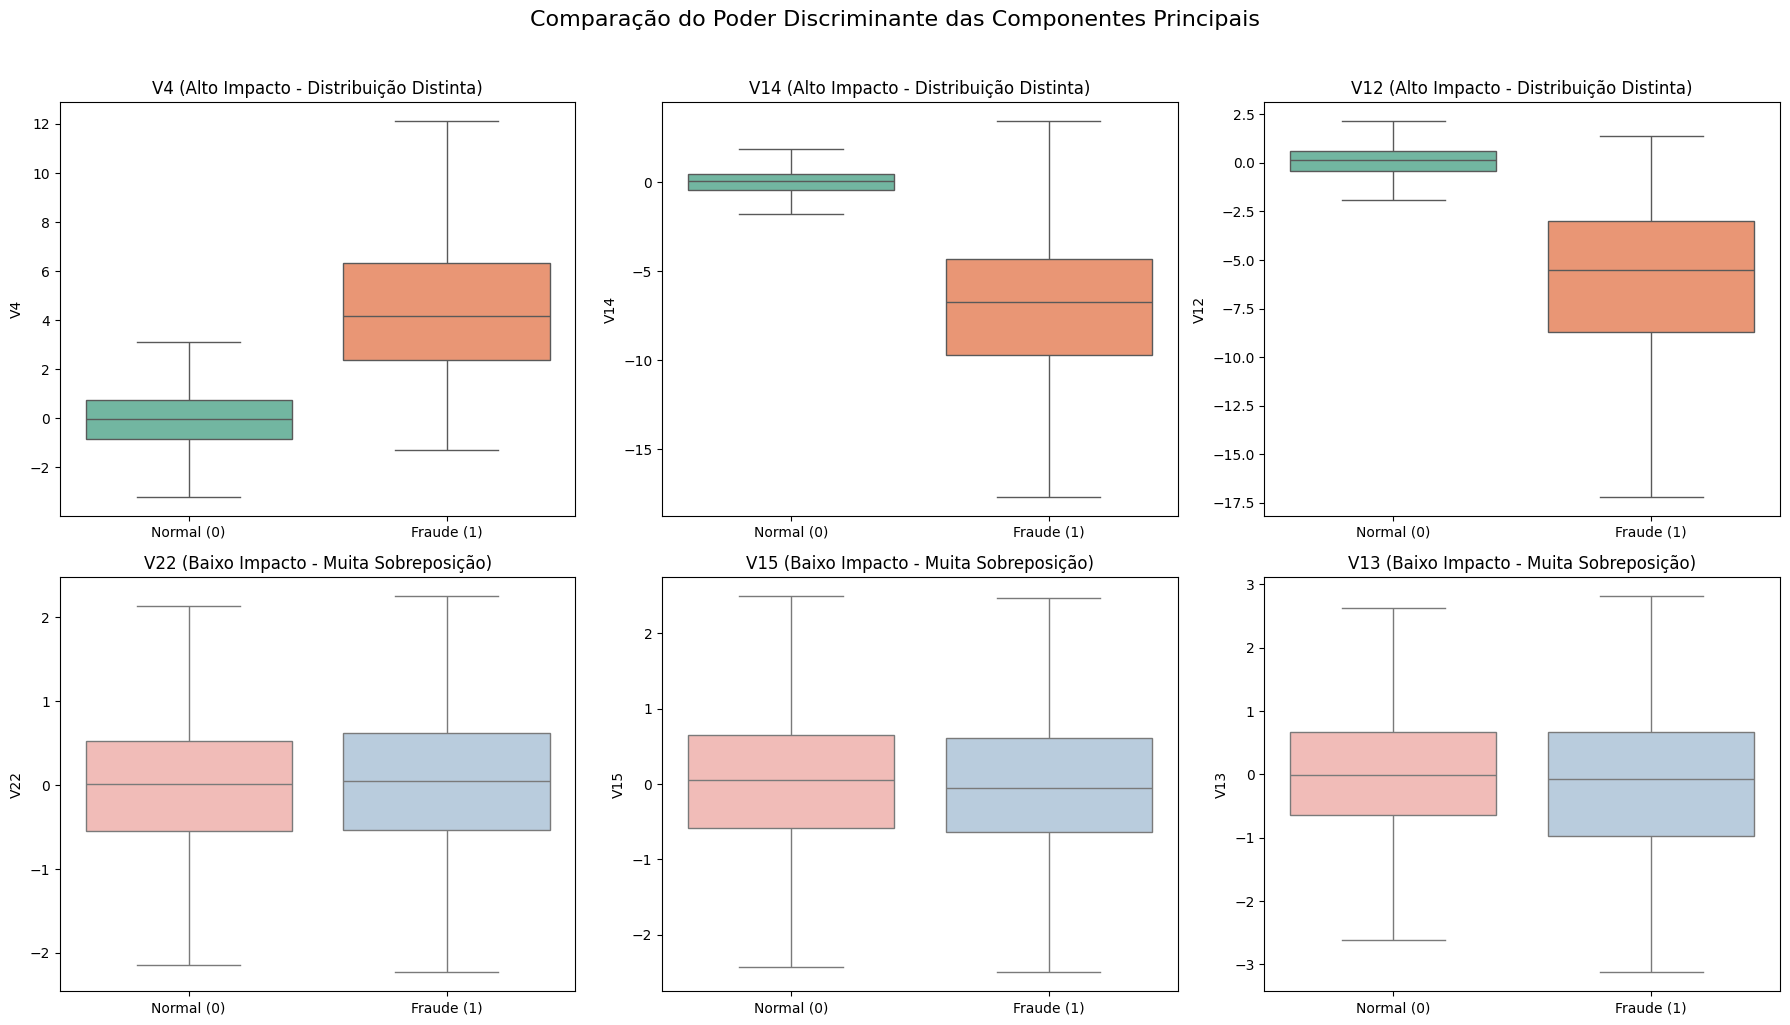

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Criar painéis de boxplots para as variáveis de Alto e Baixo Impacto
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

alto_impacto = ['V4', 'V14', 'V12']
baixo_impacto = ['V22', 'V15','V13']

# Plotando as de Alto Impacto (Primeira Linha)
for i, col in enumerate(alto_impacto):
    sns.boxplot(
        x='Class', y=col, hue='Class', data=df, 
        ax=axes[0, i], palette='Set2', showfliers=False, legend=False
    )
    axes[0, i].set_title(f'{col} (Alto Impacto - Distribuição Distinta)')
    axes[0, i].set_xticks([0, 1])
    axes[0, i].set_xticklabels(['Normal (0)', 'Fraude (1)'])
    axes[0, i].set_xlabel('')

# Plotando as de Baixo Impacto (Segunda Linha)
for i, col in enumerate(baixo_impacto):
    sns.boxplot(
        x='Class', y=col, hue='Class', data=df, 
        ax=axes[1, i], palette='Pastel1', showfliers=False, legend=False
    )
    axes[1, i].set_title(f'{col} (Baixo Impacto - Muita Sobreposição)')
    axes[1, i].set_xticks([0, 1])
    axes[1, i].set_xticklabels(['Normal (0)', 'Fraude (1)'])
    axes[1, i].set_xlabel('')

plt.suptitle('Comparação do Poder Discriminante das Componentes Principais', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2. Separação Treino, Teste e OOT

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar variáveis preditoras (X) e a variável alvo (y)
# Vamos remover 'Time' que é apenas um contador temporal para esta análise simplificada
X = df.drop(columns=['Time', 'Class'])
y = df['Class']

# 2. Dividir em treino (70%) e teste (30%) mantendo a proporção original das classes (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Escalar a variável 'Amount' que é a única não padronizada
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test_scaled['Amount'] = scaler.transform(X_test[['Amount']])

print(f"Treino - Legítimas: {sum(y_train==0)}, Fraudes: {sum(y_train==1)}")
print(f"Teste  - Legítimas: {sum(y_test==0)}, Fraudes: {sum(y_test==1)}")

Treino - Legítimas: 199020, Fraudes: 344
Teste  - Legítimas: 85295, Fraudes: 148


### 2.1. Abordagem 1: Ajuste de Pesos de Classe (class_weight='balanced')
#### Esta técnica não altera a base de dados. Ela simplesmente instrui o algoritmo a dar mais importância aos erros cometidos na classe de fraude na hora de ajustar os pesos internos da inteligência artificial.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Criando o modelo com ajuste automático de pesos
model_weighted = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Treinando o modelo
model_weighted.fit(X_train_scaled, y_train)

# Avaliando
y_pred_weighted = model_weighted.predict(X_test_scaled)

print("--- Avaliação: Ajuste de Pesos (Class Weight) ---")
print(classification_report(y_test, y_pred_weighted))

--- Avaliação: Ajuste de Pesos (Class Weight) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [6]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import pandas as pd

# Predict de probabilidade para AUC-ROC e Métricas P1/P5/P10
y_proba_weighted = model_weighted.predict_proba(X_test_scaled)[:, 1]

# Cálculo da AUC-ROC
auc_weighted = roc_auc_score(y_test, y_proba_weighted)

# Função para calcular a concentração de fraudes no Top % (P1, P5, P10)
def calcular_p_metrics(y_true, y_proba, percentiles=[1, 5, 10]):
    df_eval = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})
    df_eval = df_eval.sort_values(by='y_proba', ascending=False).reset_index(
        drop=True
    )

    total_frauds = df_eval['y_true'].sum()
    results = {}

    for p in percentiles:
        cutoff = int(np.ceil(len(df_eval) * (p / 100)))
        frauds_captured = df_eval.iloc[:cutoff]['y_true'].sum()
        results[f'P{p}'] = (frauds_captured / total_frauds) * 100

    return results


p_metrics = calcular_p_metrics(y_test, y_proba_weighted)

print('--- Métricas Complementares de Negócio ---')
print(f'AUC-ROC: {auc_weighted:.4f}')
print(f'Captura P1 (Top 1% risco): {p_metrics["P1"]:.2f}%')
print(f'Captura P5 (Top 5% risco): {p_metrics["P5"]:.2f}%')
print(f'Captura P10 (Top 10% risco): {p_metrics["P10"]:.2f}%')

--- Métricas Complementares de Negócio ---
AUC-ROC: 0.9699
Captura P1 (Top 1% risco): 85.14%
Captura P5 (Top 5% risco): 89.19%
Captura P10 (Top 10% risco): 92.57%


### 2.2. Abordagem 2: Under-sampling Dinâmico (RandomUnderSampler)
### Reduziremos a classe majoritária para criar um cenário equilibrado de treino.

In [7]:
from imblearn.under_sampling import RandomUnderSampler

# Inicializar o subamostrador para proporção de 1:1
rus = RandomUnderSampler(random_state=42)
X_resampled_under, y_resampled_under = rus.fit_resample(X_train_scaled, y_train)

print(f"Após Under-sampling no Treino:")
print(f"Legítimas: {sum(y_resampled_under==0)}, Fraudes: {sum(y_resampled_under==1)}")

# Treinar modelo na base reduzida
model_under = LogisticRegression(max_iter=1000, random_state=42)
model_under.fit(X_resampled_under, y_resampled_under)



# Avaliar
y_pred_under = model_under.predict(X_test_scaled)
print("\n--- Avaliação: Under-sampling ---")
print(classification_report(y_test, y_pred_under))

Após Under-sampling no Treino:
Legítimas: 344, Fraudes: 344

--- Avaliação: Under-sampling ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [8]:
# Avaliar probabilidades para a Técnica 2
y_proba_under = model_under.predict_proba(X_test_scaled)[:, 1]

# Cálculo da AUC-ROC
auc_under = roc_auc_score(y_test, y_proba_under)

# Métricas P1, P5 e P10
p_metrics_under = calcular_p_metrics(y_test, y_proba_under)

print("--- Métricas Complementares de Negócio (Under-sampling) ---")
print(f"AUC-ROC: {auc_under:.4f}")
print(f"Captura P1 (Top 1% risco): {p_metrics_under['P1']:.2f}%")
print(f"Captura P5 (Top 5% risco): {p_metrics_under['P5']:.2f}%")
print(f"Captura P10 (Top 10% risco): {p_metrics_under['P10']:.2f}%")

--- Métricas Complementares de Negócio (Under-sampling) ---
AUC-ROC: 0.9723
Captura P1 (Top 1% risco): 85.14%
Captura P5 (Top 5% risco): 90.54%
Captura P10 (Top 10% risco): 91.89%


### 2.3. Abordagem 3: Over-sampling Sintético com SMOTE (Synthetic Minority Over-sampling Technique)
#### O SMOTE gera novos exemplos sintéticos de fraude baseando-se nas distâncias matemáticas dos dados reais vizinhos.

In [9]:
from imblearn.over_sampling import SMOTE

# Inicializar o SMOTE para balancear a classe minoritária
smote = SMOTE(random_state=42)
X_resampled_over, y_resampled_over = smote.fit_resample(X_train_scaled, y_train)

print(f"Após SMOTE (Over-sampling) no Treino:")
print(f"Legítimas: {sum(y_resampled_over==0)}, Fraudes: {sum(y_resampled_over==1)}")

# Treinar modelo na base artificialmente ampliada
model_over = LogisticRegression(max_iter=1000, random_state=42)
model_over.fit(X_resampled_over, y_resampled_over)

# Avaliar
y_pred_over = model_over.predict(X_test_scaled)
print("\n--- Avaliação: Over-sampling (SMOTE) ---")
print(classification_report(y_test, y_pred_over))

Após SMOTE (Over-sampling) no Treino:
Legítimas: 199020, Fraudes: 199020

--- Avaliação: Over-sampling (SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [10]:
# Avaliar probabilidades para a Técnica 3 (SMOTE)
y_proba_over = model_over.predict_proba(X_test_scaled)[:, 1]

# Cálculo da AUC-ROC
auc_over = roc_auc_score(y_test, y_proba_over)

# Métricas P1, P5 e P10
p_metrics_over = calcular_p_metrics(y_test, y_proba_over)

print("--- Métricas Complementares de Negócio (SMOTE) ---")
print(f"AUC-ROC: {auc_over:.4f}")
print(f"Captura P1 (Top 1% risco): {p_metrics_over['P1']:.2f}%")
print(f"Captura P5 (Top 5% risco): {p_metrics_over['P5']:.2f}%")
print(f"Captura P10 (Top 10% risco): {p_metrics_over['P10']:.2f}%")

--- Métricas Complementares de Negócio (SMOTE) ---
AUC-ROC: 0.9677
Captura P1 (Top 1% risco): 85.14%
Captura P5 (Top 5% risco): 89.19%
Captura P10 (Top 10% risco): 91.22%


### 2.4. Comparação Visual das Matrizes de Confusão
#### Vamos plotar as três matrizes de confusão lado a lado para verificar qual método obteve a melhor sensibilidade (Recall) para detectar as fraudes sem gerar muitos alarmes falsos.

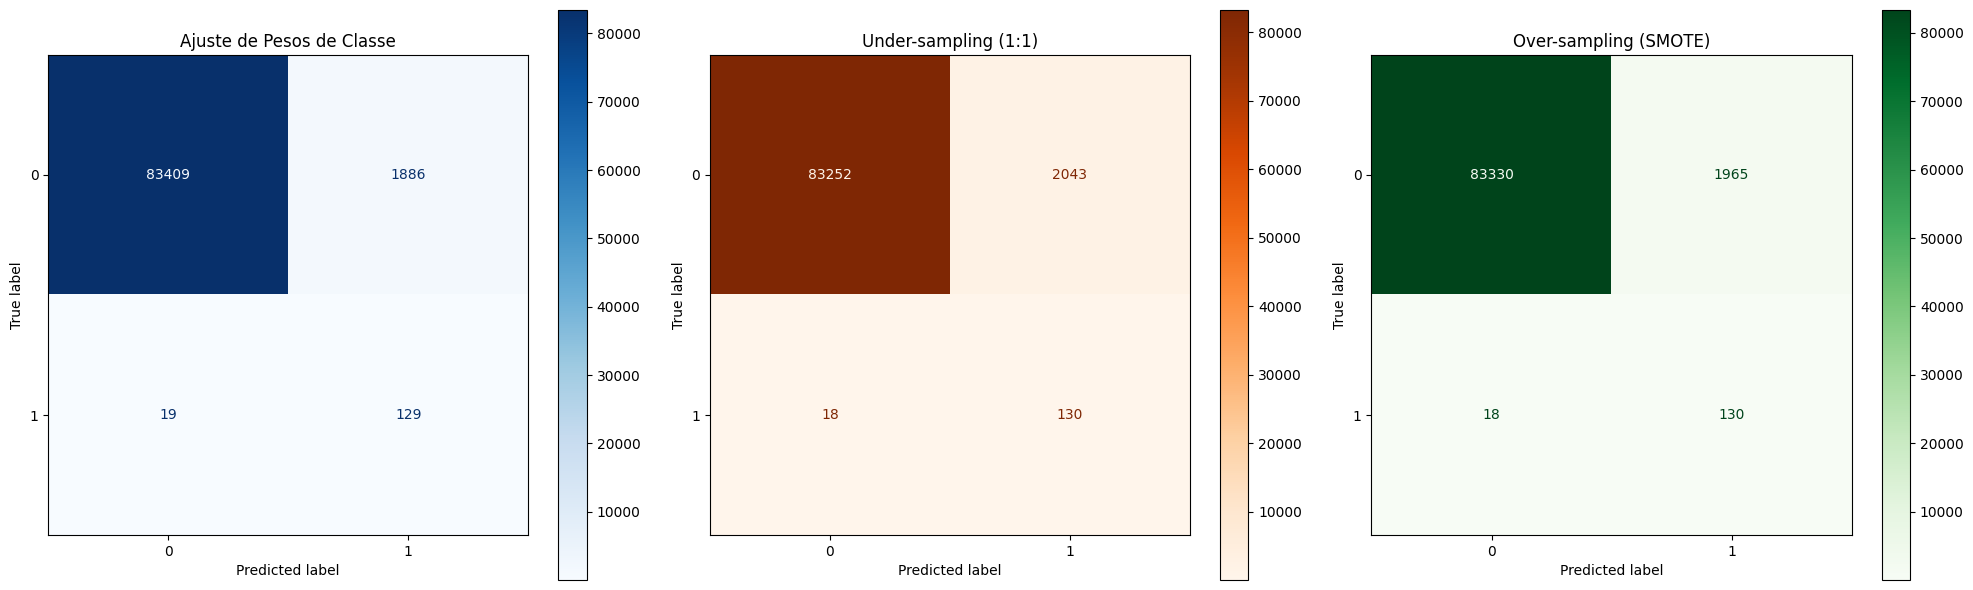

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Matriz 1: Pesos de Classe
cm_weight = confusion_matrix(y_test, y_pred_weighted)
ConfusionMatrixDisplay(confusion_matrix=cm_weight).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Ajuste de Pesos de Classe')

# Matriz 2: Under-sampling
cm_under = confusion_matrix(y_test, y_pred_under)
ConfusionMatrixDisplay(confusion_matrix=cm_under).plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title('Under-sampling (1:1)')

# Matriz 3: SMOTE
cm_over = confusion_matrix(y_test, y_pred_over)
ConfusionMatrixDisplay(confusion_matrix=cm_over).plot(ax=axes[2], cmap='Greens', values_format='d')
axes[2].set_title('Over-sampling (SMOTE)')

# plt.suptitle('Comparação de Matrizes de Confusão no Conjunto de Teste', fontsize=16)
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import precision_recall_fscore_support

# Dicionário de previsões dos modelos
modelos_previsoes = {
    'Ajuste de Pesos (Class Weight)': y_pred_weighted,
    'Under-sampling (1:1)': y_pred_under,
    'Over-sampling (SMOTE)': y_pred_over
}

resultados = []

for nome, y_pred in modelos_previsoes.items():
    # Extrair as métricas especificamente para a Classe 1 (Fraude)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[1])

    # Calcular matriz de confusão para extrair Falsos Positivos (Alarmes Falsos)
    cm = confusion_matrix(y_test, y_pred)
    falsos_positivos = cm[0, 1]
    verdadeiros_positivos = cm[1, 1]

    resultados.append({
        'Técnica': nome,
        'Precisão (Classe 1)': f"{precision[0]*100:.2f}%",
        'Recall (Sensibilidade)': f"{recall[0]*100:.2f}%",
        'F1-Score (Classe 1)': f"{f1[0]*100:.2f}%",
        'Fraudes Detectadas (TP)': f"{verdadeiros_positivos} de {sum(y_test==1)}",
        'Alarmes Falsos (FP)': falsos_positivos
    })

# Criar DataFrame para exibição limpa
df_comparacao = pd.DataFrame(resultados)
display(df_comparacao)

,Técnica,Precisão (Classe 1),Recall (Sensibilidade),F1-Score (Classe 1),Fraudes Detectadas (TP),Alarmes Falsos (FP)
0,Ajuste de Pesos (Class Weight),6.40%,87.16%,11.93%,129 de 148,1886
1,Under-sampling (1:1),5.98%,87.84%,11.20%,130 de 148,2043
2,Over-sampling (SMOTE),6.21%,87.84%,11.59%,130 de 148,1965


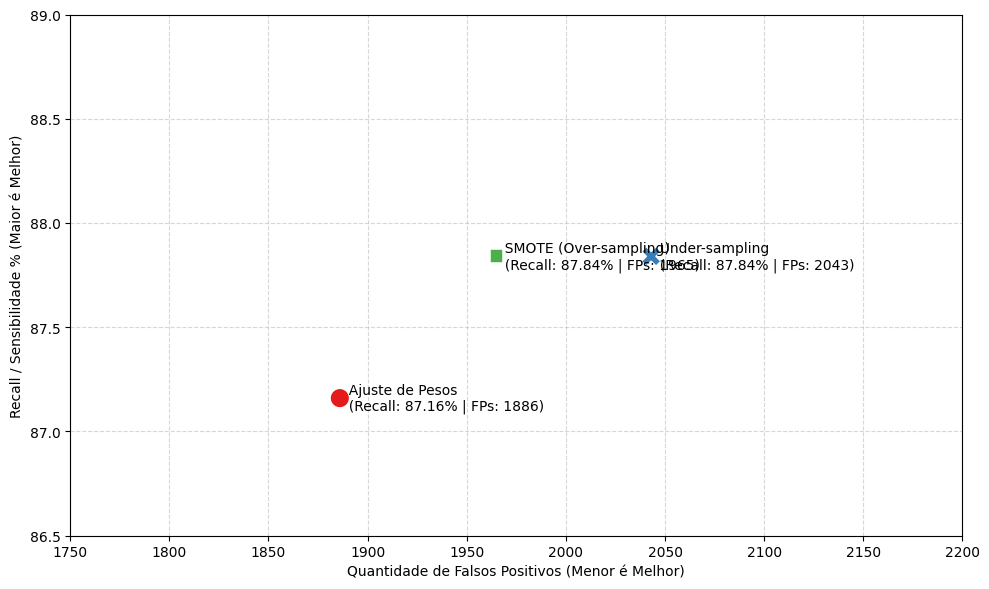

In [51]:
# Extraindo os dados numéricos para o gráfico
recalls = [87.16, 87.84, 87.84]
fps = [1886, 2043, 1965]
tecnicas = ['Ajuste de Pesos', 'Under-sampling', 'SMOTE (Over-sampling)']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fps, y=recalls, hue=tecnicas, style=tecnicas, s=200, palette='Set1')

# Adicionar anotações para cada ponto
for i, txt in enumerate(tecnicas):
    plt.annotate(f"  {txt}\n  (Recall: {recalls[i]}% | FPs: {fps[i]})",
                 (fps[i], recalls[i]),
                 fontsize=10,
                 va='center')
#
# plt.title('Análise de Trade-off: Sensibilidade vs. Alarmes Falsos', fontsize=14)
plt.xlabel('Quantidade de Falsos Positivos (Menor é Melhor)')
plt.ylabel('Recall / Sensibilidade % (Maior é Melhor)')
plt.xlim(1750, 2200)
plt.ylim(86.5, 89.0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend().remove() # Remover legenda padrão pois já anotamos os pontos
plt.tight_layout()
plt.show()

### 3. Testando Diferentes Algoritmos de Machine Learning

Nesta etapa, vamos treinar e comparar três modelos robustos de classificação utilizando o ajuste de pesos de classe para lidar com o desbalanceamento:

Regressão Logística (Modelo Linear) \
Random Forest Classifier (Modelo Ensemble - Bagging) \
XGBoost Classifier (Modelo Ensemble - Boosting) 


Avaliaremos cada um no conjunto de teste usando Precision, Recall, F1-Score e a curva Precision-Recall (ideal para dados altamente desbalanceados).

In [52]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Calcular a proporção de peso para o XGBoost (scale_pos_weight)
# ratio = total_negative_examples / total_positive_examples
ratio = sum(y_train == 0) / sum(y_train == 1)

# 1. Inicializar os modelos comparativos
modelos = {
    'Regressão Logística (Baseline)': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest (Balanced)': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost (Weighted)': XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
}

# Dicionário para guardar as previsões e probabilidades
previsoes_prob = {}
resultados_ml = []

# 2. Treinar e avaliar cada modelo
for nome, modelo in modelos.items():
    print(f"Treinando {nome}...")
    modelo.fit(X_train_scaled, y_train)

    # Previsões de classe e probabilidades da classe 1
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    previsoes_prob[nome] = {'pred': y_pred, 'prob': y_prob}

    # Métricas numéricas
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[1])
    cm = confusion_matrix(y_test, y_pred)

    resultados_ml.append({
        'Algoritmo': nome,
        'Precisão (Fraude)': f"{precision[0]*100:.2f}%",
        'Recall (Fraude)': f"{recall[0]*100:.2f}%",
        'F1-Score (Fraude)': f"{f1[0]*100:.2f}%",
        'Fraudes Detectadas (TP)': cm[1, 1],
        'Alarmes Falsos (FP)': cm[0, 1]
    })

df_resultados_ml = pd.DataFrame(resultados_ml)
display(df_resultados_ml)

Treinando Regressão Logística (Baseline)...
Treinando Random Forest (Balanced)...
Treinando XGBoost (Weighted)...


,Algoritmo,Precisão (Fraude),Recall (Fraude),F1-Score (Fraude),Fraudes Detectadas (TP),Alarmes Falsos (FP)
0,Regressão Logística (Baseline),6.40%,87.16%,11.93%,129,1886
1,Random Forest (Balanced),97.20%,70.27%,81.57%,104,3
2,XGBoost (Weighted),87.88%,78.38%,82.86%,116,16


In [53]:
from catboost import CatBoostClassifier

# 1. Inicializar e adicionar o CatBoost aos nossos modelos de teste
# scale_pos_weight funciona de forma idêntica ao XGBoost
modelo_cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    verbose=0
)

print("Treinando CatBoost...")
modelo_cat.fit(X_train_scaled, y_train)

# 2. Obter previsões e probabilidades
y_pred_cat = modelo_cat.predict(X_test_scaled)
y_prob_cat = modelo_cat.predict_proba(X_test_scaled)[:, 1]

# Adicionar os dados no nosso dicionário de probabilidades para o gráfico final
previsoes_prob['CatBoost (Weighted)'] = {'pred': y_pred_cat, 'prob': y_prob_cat}

# 3. Calcular métricas do CatBoost
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_cat, average=None, labels=[1])
cm = confusion_matrix(y_test, y_pred_cat)

# Adicionar à lista existente de resultados de Machine Learning
resultados_ml.append({
    'Algoritmo': 'CatBoost (Weighted)',
    'Precisão (Fraude)': f"{precision[0]*100:.2f}%",
    'Recall (Fraude)': f"{recall[0]*100:.2f}%",
    'F1-Score (Fraude)': f"{f1[0]*100:.2f}%",
    'Fraudes Detectadas (TP)': cm[1, 1],
    'Alarmes Falsos (FP)': cm[0, 1]
})

# Atualizar o DataFrame de comparação
df_resultados_ml_atualizado = pd.DataFrame(resultados_ml)
display(df_resultados_ml_atualizado)

Treinando CatBoost...


,Algoritmo,Precisão (Fraude),Recall (Fraude),F1-Score (Fraude),Fraudes Detectadas (TP),Alarmes Falsos (FP)
0,Regressão Logística (Baseline),6.40%,87.16%,11.93%,129,1886
1,Random Forest (Balanced),97.20%,70.27%,81.57%,104,3
2,XGBoost (Weighted),87.88%,78.38%,82.86%,116,16
3,CatBoost (Weighted),73.01%,80.41%,76.53%,119,44


In [55]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1. Inicializar LightGBM e CatBoost com scale_pos_weight
modelo_lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

modelo_cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    verbose=0
)

# Adicionar os novos modelos ao dicionário de execução ou treinar sequencialmente
novos_modelos = {
    'LightGBM (Weighted)': modelo_lgbm,
    'CatBoost (Weighted)': modelo_cat
}

# 2. Treinar, prever e calcular métricas para ambos
for nome, modelo in novos_modelos.items():
    print(f"Treinando {nome}...")
    modelo.fit(X_train_scaled, y_train)

    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    # Armazenar previsões e probabilidades para o gráfico AUPRC
    previsoes_prob[nome] = {'pred': y_pred, 'prob': y_prob}

    # Métricas numéricas
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[1])
    cm = confusion_matrix(y_test, y_pred)

    resultados_ml.append({
        'Algoritmo': nome,
        'Precisão (Fraude)': f"{precision[0]*100:.2f}%",
        'Recall (Fraude)': f"{recall[0]*100:.2f}%",
        'F1-Score (Fraude)': f"{f1[0]*100:.2f}%",
        'Fraudes Detectadas (TP)': cm[1, 1],
        'Alarmes Falsos (FP)': cm[0, 1]
    })

# 3. Atualizar o DataFrame consolidado
df_resultados_ml_atualizado = pd.DataFrame(resultados_ml)
display(df_resultados_ml_atualizado)

Treinando LightGBM (Weighted)...
Treinando CatBoost (Weighted)...


,Algoritmo,Precisão (Fraude),Recall (Fraude),F1-Score (Fraude),Fraudes Detectadas (TP),Alarmes Falsos (FP)
0,Regressão Logística (Baseline),6.40%,87.16%,11.93%,129,1886
1,Random Forest (Balanced),97.20%,70.27%,81.57%,104,3
2,XGBoost (Weighted),87.88%,78.38%,82.86%,116,16
3,CatBoost (Weighted),73.01%,80.41%,76.53%,119,44
4,LightGBM (Weighted),1.92%,83.78%,3.76%,124,6330
5,CatBoost (Weighted),73.01%,80.41%,76.53%,119,44


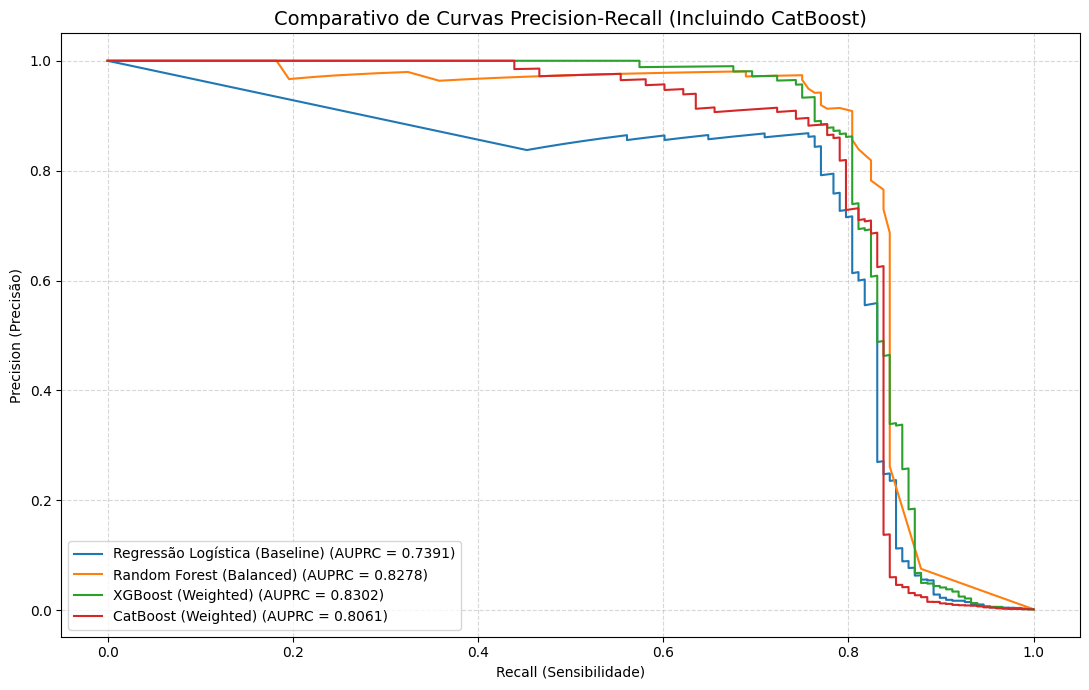

In [54]:
plt.figure(figsize=(11, 7))

for nome, dados in previsoes_prob.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, dados['prob'])
    auc_score = auc(recall_curve, precision_curve)
    plt.plot(recall_curve, precision_curve, label=f'{nome} (AUPRC = {auc_score:.4f})')

plt.title('Comparativo de Curvas Precision-Recall (Incluindo CatBoost)', fontsize=14)
plt.xlabel('Recall (Sensibilidade)')
plt.ylabel('Precision (Precisão)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### 4. Refinando Amostragem e Técnicas Campeas 

In [53]:
import pandas as pd
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

# 2. Peso de classe
ratio = sum(y_train == 0) / sum(y_train == 1)

def objective_parcimonioso(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 40, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),                 # Profundidade reduzida (2 a 4)
        'min_child_weight': trial.suggest_int('min_child_weight', 15, 50),     # Maior exigência de amostras por nó
        'subsample': trial.suggest_float('subsample', 0.5, 0.75),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.75),
        'gamma': trial.suggest_float('gamma', 0.5, 8.0, log=True),        # Força a poda ativamente
        'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 20.0, log=True),    # L1 mais forte
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 20.0, log=True),   # L2 mais forte
        'scale_pos_weight': ratio,
        'random_state': 42,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # Métricas de Treino e Teste
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]
    test_pr_auc = average_precision_score(y_test, y_test_pred_proba)

    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    train_pr_auc = average_precision_score(y_train, y_train_pred_proba)

    gap = train_pr_auc - test_pr_auc

    # Atributos salvos para a ordenação e gráficos posteriores
    trial.set_user_attr('train_pr_auc', train_pr_auc)
    trial.set_user_attr('test_pr_auc', test_pr_auc)
    trial.set_user_attr('gap', gap)

    # Penalização RÍGIDA se o gap ultrapassar 10%
    penalidade = max(0, gap - 0.05) * 3.0
    return test_pr_auc - penalidade

# 3. Rodar o Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_top15 = optuna.create_study(direction='maximize')
study_top15.optimize(objective_parsimonioso, n_trials=30)

# 4. Consolidar os resultados
results_optuna = []
for trial in study_top15.trials:
    train_auc = trial.user_attrs.get('train_pr_auc')
    test_auc = trial.user_attrs.get('test_pr_auc')
    gap = trial.user_attrs.get('gap')

    if train_auc is not None and test_auc is not None:
        results_optuna.append({
            'trial_number': trial.number,
            'train_pr_auc': f"{train_auc*100:.2f}%",
            'test_pr_auc': f"{test_auc*100:.2f}%",
            'pr_auc_difference': f"{gap*100:.2f}%",
            'test_pr_auc_num': test_auc,
            'gap_num': gap,
            'hyperparameters': trial.params
        })

# Criar DataFrame consolidado
results_optuna_df = pd.DataFrame(results_optuna)

# Ordenar dando prioridade para Menor Gap e Maior Teste
results_optuna_df_sorted = results_optuna_df.sort_values(
    by=['gap_num', 'test_pr_auc_num'], 
    ascending=[True, False]
)

# Exibir os 10 melhores resultados
display(results_optuna_df_sorted[['trial_number', 'train_pr_auc', 'test_pr_auc', 'pr_auc_difference']].head(30))

,trial_number,train_pr_auc,test_pr_auc,pr_auc_difference
14,14,78.92%,71.40%,7.52%
15,15,74.13%,66.03%,8.10%
24,24,74.31%,66.06%,8.25%
11,11,75.67%,67.19%,8.48%
20,20,79.41%,70.82%,8.59%
12,12,74.99%,66.37%,8.62%
6,6,76.98%,68.22%,8.76%
10,10,75.36%,66.56%,8.80%
18,18,74.09%,65.21%,8.88%
13,13,76.75%,67.76%,8.99%


In [54]:
# Digite aqui o número do trial desejado
chosen_trial_number = 14

best_params = study_top15.trials[chosen_trial_number].params.copy()
best_params['scale_pos_weight'] = ratio
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['n_jobs'] = -1

xgb_best_model = XGBClassifier(**best_params)
xgb_best_model.fit(X_train_scaled, y_train, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5675683281893795, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=0.9991751065468705, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.036575959761585,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=21, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=143, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [55]:
import pandas as pd
from xgboost import XGBClassifier

# Garantir que os parâmetros fixos fiquem presentes
best_params['scale_pos_weight'] = ratio
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['n_jobs'] = -1

# 2. Treinar o modelo final com todos os recursos escalados (X_train_scaled)
xgb_best_model = XGBClassifier(**best_params)
xgb_best_model.fit(X_train_scaled, y_train, verbose=False)

# 3. Criar o DataFrame de importância das variáveis
feature_importance_df = pd.DataFrame({
    'Variavel': X_train_scaled.columns,
    'Importancia': xgb_best_model.feature_importances_
}).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

# 4. Criar a lista 'ordered_features' usada para selecionar o Top 15 nos passos anteriores
ordered_features = feature_importance_df['Variavel'].tolist()

print("--- Variáveis Ordenadas por Importância (Melhor Modelo Optuna) ---")
display(feature_importance_df)

--- Variáveis Ordenadas por Importância (Melhor Modelo Optuna) ---


,Variavel,Importancia
0,V14,0.212171
1,V12,0.123384
2,V10,0.106520
3,V4,0.069581
4,V17,0.053928
5,V11,0.038427
6,V3,0.027829
7,Amount,0.027362
8,V21,0.026406
9,V7,0.023791


--- Rodando Seleção Progressiva de Atributos (Treino vs Teste) ---
Passo 01: 'V14' | AUPRC (Tr/Te): 56.34% / 52.84% | Recall (Tr/Te): 88.66% / 83.78%
Passo 02: 'V12' | AUPRC (Tr/Te): 76.22% / 70.61% | Recall (Tr/Te): 90.12% / 83.11%
Passo 03: 'V10' | AUPRC (Tr/Te): 78.11% / 72.59% | Recall (Tr/Te): 90.12% / 83.11%
Passo 04: 'V4' | AUPRC (Tr/Te): 78.39% / 69.16% | Recall (Tr/Te): 92.73% / 87.84%
Passo 05: 'V17' | AUPRC (Tr/Te): 78.36% / 70.50% | Recall (Tr/Te): 92.15% / 87.16%
Passo 06: 'V11' | AUPRC (Tr/Te): 78.91% / 70.92% | Recall (Tr/Te): 92.73% / 87.16%
Passo 07: 'V3' | AUPRC (Tr/Te): 69.46% / 71.29% | Recall (Tr/Te): 92.73% / 87.84%
Passo 08: 'Amount' | AUPRC (Tr/Te): 77.77% / 71.27% | Recall (Tr/Te): 94.19% / 87.16%
Passo 09: 'V21' | AUPRC (Tr/Te): 76.01% / 65.67% | Recall (Tr/Te): 93.60% / 87.16%
Passo 10: 'V7' | AUPRC (Tr/Te): 76.64% / 67.89% | Recall (Tr/Te): 93.90% / 87.84%
Passo 11: 'V19' | AUPRC (Tr/Te): 77.04% / 67.46% | Recall (Tr/Te): 94.19% / 87.84%
Passo 12: 'V8' | AUP

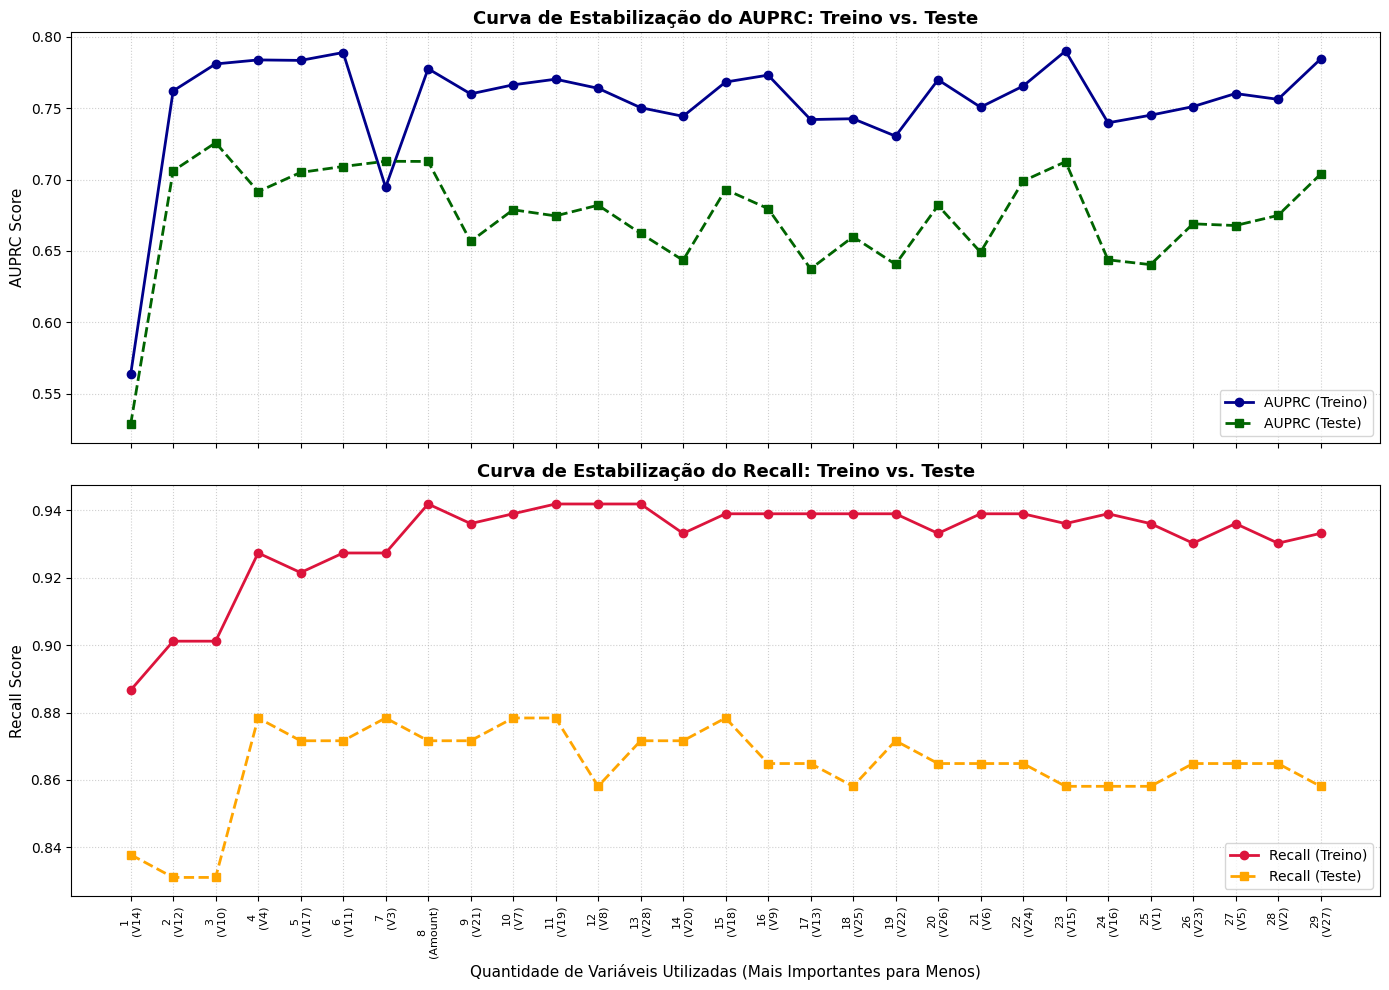

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc, precision_recall_fscore_support

# 1. Recuperar hiperparâmetros do melhor trial do Optuna
best_params = study_top15.best_trial.params.copy()
best_params['scale_pos_weight'] = ratio
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['n_jobs'] = -1

# 2. Treinar modelo com todas as variáveis para obter a importância real
xgb_base = XGBClassifier(**best_params)
xgb_base.fit(X_train_scaled, y_train, verbose=False)

feature_importance_df = pd.DataFrame({
    'Variavel': X_train_scaled.columns,
    'Importancia': xgb_base.feature_importances_
}).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

ordered_features = feature_importance_df['Variavel'].tolist()

# 3. Listas para armazenar os dados do gráfico (Treino e Teste)
historico_features = []
auprc_train_list = []
auprc_test_list = []
recall_train_list = []
recall_test_list = []

print("--- Rodando Seleção Progressiva de Atributos (Treino vs Teste) ---")

# 4. Loop progressivo (variável por variável)
for i in range(1, len(ordered_features) + 1):
    features_subset = ordered_features[:i]

    # Treinar modelo XGBoost com subconjunto de variáveis
    model_temp = XGBClassifier(**best_params)
    model_temp.fit(X_train_scaled[features_subset], y_train, verbose=False)

    # --- AVALIAÇÃO NO TREINO ---
    y_probs_train = model_temp.predict_proba(X_train_scaled[features_subset])[:, 1]
    prec_tr, rec_tr_curve, _ = precision_recall_curve(y_train, y_probs_train)
    auprc_train = auc(rec_tr_curve, prec_tr)
    
    y_pred_train = model_temp.predict(X_train_scaled[features_subset])
    _, rec_tr, _, _ = precision_recall_fscore_support(y_train, y_pred_train, average=None, labels=[1])

    # --- AVALIAÇÃO NO TESTE ---
    y_probs_test = model_temp.predict_proba(X_test_scaled[features_subset])[:, 1]
    prec_te, rec_te_curve, _ = precision_recall_curve(y_test, y_probs_test)
    auprc_test = auc(rec_te_curve, prec_te)
    
    y_pred_test = model_temp.predict(X_test_scaled[features_subset])
    _, rec_te, _, _ = precision_recall_fscore_support(y_test, y_pred_test, average=None, labels=[1])

    # Guardar métricas
    historico_features.append(i)
    auprc_train_list.append(auprc_train)
    auprc_test_list.append(auprc_test)
    recall_train_list.append(rec_tr[0])
    recall_test_list.append(rec_te[0])

    print(f"Passo {i:02d}: '{ordered_features[i-1]}' | "
          f"AUPRC (Tr/Te): {auprc_train*100:.2f}% / {auprc_test*100:.2f}% | "
          f"Recall (Tr/Te): {rec_tr[0]*100:.2f}% / {rec_te[0]*100:.2f}%")

# 5. Plotagem em 2 Subplots (AUPRC e Recall lado a lado/sobrepostos)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

labels_x = [f"{i}\n({ordered_features[i-1]})" for i in range(1, len(ordered_features) + 1)]

# Painel 1: AUPRC (Treino vs Teste)
ax1.plot(historico_features, auprc_train_list, marker='o', color='darkblue', linewidth=2, label='AUPRC (Treino)')
ax1.plot(historico_features, auprc_test_list, marker='s', color='darkgreen', linewidth=2, linestyle='--', label='AUPRC (Teste)')
ax1.set_title('Curva de Estabilização do AUPRC: Treino vs. Teste', fontsize=13, fontweight='bold')
ax1.set_ylabel('AUPRC Score', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10, loc='lower right')

# Painel 2: Recall (Treino vs Teste)
ax2.plot(historico_features, recall_train_list, marker='o', color='crimson', linewidth=2, label='Recall (Treino)')
ax2.plot(historico_features, recall_test_list, marker='s', color='orange', linewidth=2, linestyle='--', label='Recall (Teste)')
ax2.set_title('Curva de Estabilização do Recall: Treino vs. Teste', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quantidade de Variáveis Utilizadas (Mais Importantes para Menos)', fontsize=11)
ax2.set_ylabel('Recall Score', fontsize=11)
ax2.set_xticks(historico_features)
ax2.set_xticklabels(labels_x, rotation=90, fontsize=8)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

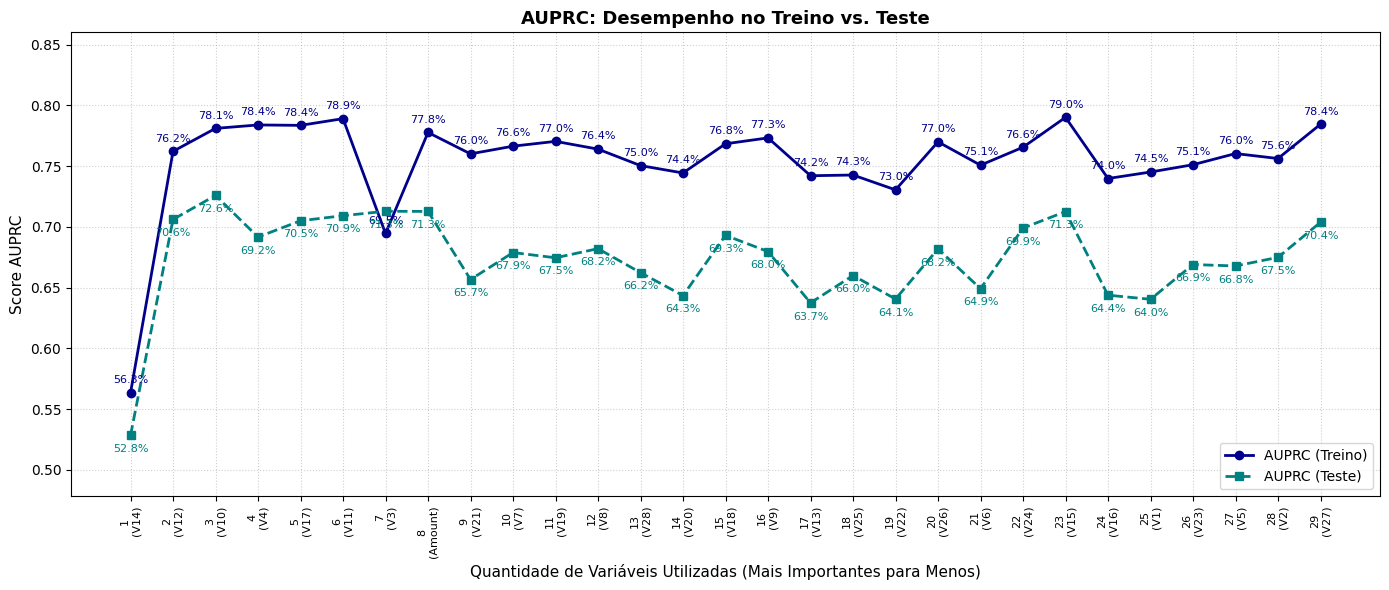

In [60]:
import matplotlib.pyplot as plt

# 1. Gráfico exclusivo para AUPRC
plt.figure(figsize=(14, 6))

plt.plot(historico_features, auprc_train_list, marker='o', color='darkblue', linewidth=2, label='AUPRC (Treino)')
plt.plot(historico_features, auprc_test_list, marker='s', color='teal', linewidth=2, linestyle='--', label='AUPRC (Teste)')

# Rótulos com percentuais para cada ponto
for x, y_tr, y_te in zip(historico_features, auprc_train_list, auprc_test_list):
    # Treino (acima do ponto)
    plt.annotate(f"{y_tr*100:.1f}%", (x, y_tr), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8, color='darkblue')
    # Teste (abaixo do ponto)
    plt.annotate(f"{y_te*100:.1f}%", (x, y_te), textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8, color='teal')

plt.title('AUPRC: Desempenho no Treino vs. Teste', fontsize=13, fontweight='bold')
plt.xlabel('Quantidade de Variáveis Utilizadas (Mais Importantes para Menos)', fontsize=11)
plt.ylabel('Score AUPRC', fontsize=11)

# Eixo X com o nome das variáveis
plt.xticks(
    historico_features, 
    labels=[f"{i}\n({ordered_features[i-1]})" for i in range(1, len(ordered_features) + 1)], 
    rotation=90, 
    fontsize=8
)

# Limites do Eixo Y ajustados para os valores caberem confortavelmente
min_auprc = min(min(auprc_train_list), min(auprc_test_list))
max_auprc = max(max(auprc_train_list), max(auprc_test_list))
plt.ylim(min_auprc - 0.05, max_auprc + 0.07)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

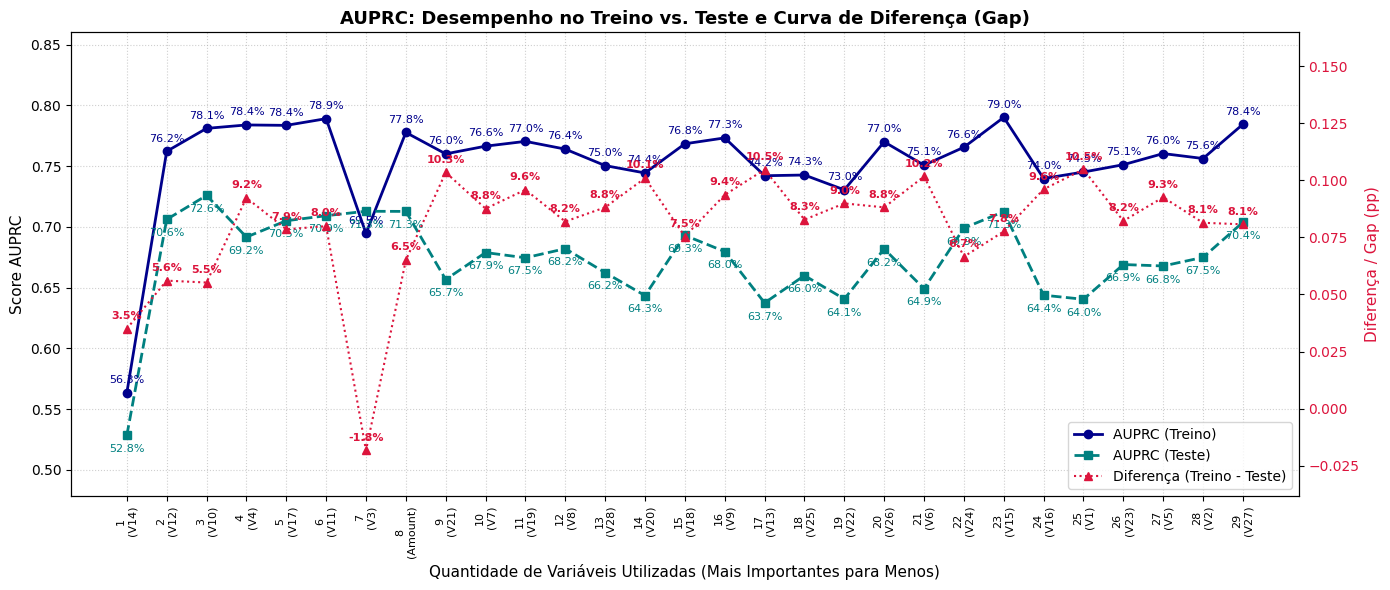

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular a diferença (Gap = Treino - Teste)
auprc_diff = [tr - te for tr, te in zip(auprc_train_list, auprc_test_list)]

fig, ax1 = plt.subplots(figsize=(14, 6))

# --- EIXO Y PRINCIPAL (ESQUERDA): Treino e Teste ---
line1 = ax1.plot(historico_features, auprc_train_list, marker='o', color='darkblue', linewidth=2, label='AUPRC (Treino)')
line2 = ax1.plot(historico_features, auprc_test_list, marker='s', color='teal', linewidth=2, linestyle='--', label='AUPRC (Teste)')

# Rótulos de percentual para Treino e Teste
for x, y_tr, y_te in zip(historico_features, auprc_train_list, auprc_test_list):
    ax1.annotate(f"{y_tr*100:.1f}%", (x, y_tr), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8, color='darkblue')
    ax1.annotate(f"{y_te*100:.1f}%", (x, y_te), textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8, color='teal')

ax1.set_xlabel('Quantidade de Variáveis Utilizadas (Mais Importantes para Menos)', fontsize=11)
ax1.set_ylabel('Score AUPRC', fontsize=11, color='black')
ax1.set_xticks(historico_features)
ax1.set_xticklabels([f"{i}\n({ordered_features[i-1]})" for i in range(1, len(ordered_features) + 1)], rotation=90, fontsize=8)

min_auprc = min(min(auprc_train_list), min(auprc_test_list))
max_auprc = max(max(auprc_train_list), max(auprc_test_list))
ax1.set_ylim(min_auprc - 0.05, max_auprc + 0.07)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- EIXO Y SECUNDÁRIO (DIREITA): Diferença (Gap) ---
ax2 = ax1.twinx()
line3 = ax2.plot(historico_features, auprc_diff, marker='^', color='crimson', linewidth=1.5, linestyle=':', label='Diferença (Treino - Teste)')

# Rótulos para a linha de diferença
for x, diff in zip(historico_features, auprc_diff):
    ax2.annotate(f"{diff*100:.1f}%", (x, diff), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8, color='crimson', fontweight='bold')

ax2.set_ylabel('Diferença / Gap (pp)', fontsize=11, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(min(auprc_diff) - 0.02, max(auprc_diff) + 0.06)

# Unificar as legendas dos dois eixos em um só quadro
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=10)

plt.title('AUPRC: Desempenho no Treino vs. Teste e Curva de Diferença (Gap)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

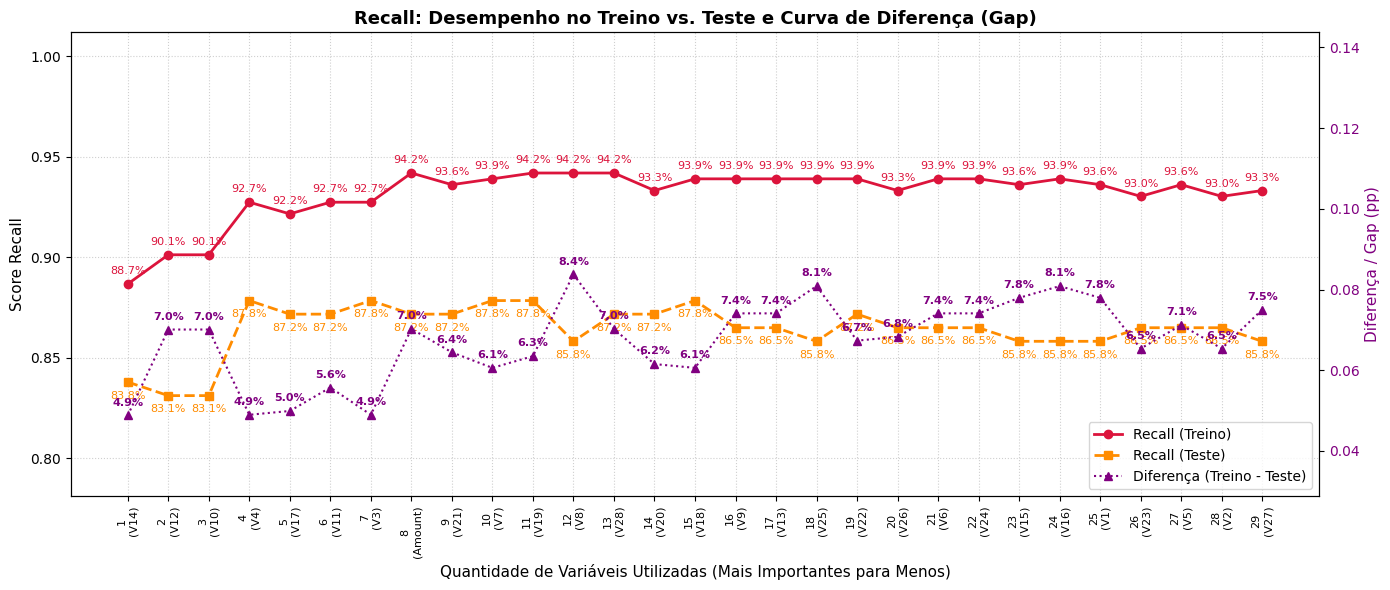

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Calcular a diferença do Recall
recall_diff = [tr - te for tr, te in zip(recall_train_list, recall_test_list)]

fig, ax1 = plt.subplots(figsize=(14, 6))

# --- EIXO Y PRINCIPAL (ESQUERDA) ---
line1 = ax1.plot(historico_features, recall_train_list, marker='o', color='crimson', linewidth=2, label='Recall (Treino)')
line2 = ax1.plot(historico_features, recall_test_list, marker='s', color='darkorange', linewidth=2, linestyle='--', label='Recall (Teste)')

for x, y_tr, y_te in zip(historico_features, recall_train_list, recall_test_list):
    ax1.annotate(f"{y_tr*100:.1f}%", (x, y_tr), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8, color='crimson')
    ax1.annotate(f"{y_te*100:.1f}%", (x, y_te), textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8, color='darkorange')

ax1.set_xlabel('Quantidade de Variáveis Utilizadas (Mais Importantes para Menos)', fontsize=11)
ax1.set_ylabel('Score Recall', fontsize=11)
ax1.set_xticks(historico_features)
ax1.set_xticklabels([f"{i}\n({ordered_features[i-1]})" for i in range(1, len(ordered_features) + 1)], rotation=90, fontsize=8)

min_rec = min(min(recall_train_list), min(recall_test_list))
max_rec = max(max(recall_train_list), max(recall_test_list))
ax1.set_ylim(min_rec - 0.05, max_rec + 0.07)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- EIXO Y SECUNDÁRIO (DIREITA) ---
ax2 = ax1.twinx()
line3 = ax2.plot(historico_features, recall_diff, marker='^', color='purple', linewidth=1.5, linestyle=':', label='Diferença (Treino - Teste)')

for x, diff in zip(historico_features, recall_diff):
    ax2.annotate(f"{diff*100:.1f}%", (x, diff), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8, color='purple', fontweight='bold')

ax2.set_ylabel('Diferença / Gap (pp)', fontsize=11, color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.set_ylim(min(recall_diff) - 0.02, max(recall_diff) + 0.06)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=10)

plt.title('Recall: Desempenho no Treino vs. Teste e Curva de Diferença (Gap)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Refinando Modelos com as 15 variáveis melhores

In [69]:
import pandas as pd
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

# 1. Subconjunto das 15 variáveis
top_15_features = ordered_features[:15]
X_train_top15 = X_train_scaled[top_15_features]
X_test_top15 = X_test_scaled[top_15_features]

# 2. Peso de classe
ratio = sum(y_train == 0) / sum(y_train == 1)

def objective_parcimonioso(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 40, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 4),                 # Profundidade reduzida (2 a 4)
        'min_child_weight': trial.suggest_int('min_child_weight', 15, 50),     # Maior exigência de amostras por nó
        'subsample': trial.suggest_float('subsample', 0.5, 0.75),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.75),
        'gamma': trial.suggest_float('gamma', 0.5, 8.0, log=True),        # Força a poda ativamente
        'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 20.0, log=True),    # L1 mais forte
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 20.0, log=True),   # L2 mais forte
        'scale_pos_weight': ratio,
        'random_state': 42,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }

    model = XGBClassifier(**params)
    # AJUSTE: Utilizando X_train_top15 e X_test_top15
    model.fit(X_train_top15, y_train, eval_set=[(X_test_top15, y_test)], verbose=False)

    # Métricas de Treino e Teste com o conjunto de 15 variáveis
    y_test_pred_proba = model.predict_proba(X_test_top15)[:, 1]
    test_pr_auc = average_precision_score(y_test, y_test_pred_proba)

    y_train_pred_proba = model.predict_proba(X_train_top15)[:, 1]
    train_pr_auc = average_precision_score(y_train, y_train_pred_proba)

    gap = train_pr_auc - test_pr_auc

    # Atributos salvos para a ordenação e gráficos posteriores
    trial.set_user_attr('train_pr_auc', train_pr_auc)
    trial.set_user_attr('test_pr_auc', test_pr_auc)
    trial.set_user_attr('gap', gap)

    # Penalização RÍGIDA se o gap ultrapassar 10%
    penalidade = max(0, gap - 0.05) * 3.0
    return test_pr_auc - penalidade

# 3. Rodar o Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_top15 = optuna.create_study(direction='maximize')
study_top15.optimize(objective_parsimonioso, n_trials=100)

# 4. Consolidar os resultados
results_optuna = []
for trial in study_top15.trials:
    train_auc = trial.user_attrs.get('train_pr_auc')
    test_auc = trial.user_attrs.get('test_pr_auc')
    gap = trial.user_attrs.get('gap')

    if train_auc is not None and test_auc is not None:
        results_optuna.append({
            'trial_number': trial.number,
            'train_pr_auc': f"{train_auc*100:.2f}%",
            'test_pr_auc': f"{test_auc*100:.2f}%",
            'pr_auc_difference': f"{gap*100:.2f}%",
            'test_pr_auc_num': test_auc,
            'gap_num': gap,
            'hyperparameters': trial.params
        })

# Criar DataFrame consolidado
results_optuna_df = pd.DataFrame(results_optuna)

# Ordenar dando prioridade para Menor Gap e Maior Teste
results_optuna_df_sorted = results_optuna_df.sort_values(
    by=['gap_num', 'test_pr_auc_num'], 
    ascending=[True, False]
)

# Exibir os 10 melhores resultados
display(results_optuna_df_sorted[['trial_number', 'train_pr_auc', 'test_pr_auc', 'pr_auc_difference']].head(30))

,trial_number,train_pr_auc,test_pr_auc,pr_auc_difference
51,51,75.35%,67.73%,7.62%
56,56,78.28%,70.64%,7.64%
54,54,74.30%,66.64%,7.66%
80,80,76.61%,68.93%,7.68%
33,33,75.11%,67.42%,7.69%
89,89,78.18%,70.44%,7.74%
64,64,78.01%,70.21%,7.80%
95,95,78.20%,70.38%,7.82%
86,86,77.53%,69.70%,7.83%
83,83,78.05%,70.19%,7.85%


In [70]:
# Digite aqui o número do trial desejado
chosen_trial_number = 56

best_params = study_top15.trials[chosen_trial_number].params.copy()
best_params['scale_pos_weight'] = ratio
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['n_jobs'] = -1

xgb_best_model = XGBClassifier(**best_params)
xgb_best_model.fit(X_train_scaled, y_train, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.541737134150597, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=1.199631516681971, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.045969412151699474,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=30, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=140, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

--- MELHORES HIPERPARÂMETROS ENCONTRADOS ---
n_estimators: 140
learning_rate: 0.045969412151699474
max_depth: 2
min_child_weight: 30
subsample: 0.6021957979766978
colsample_bytree: 0.541737134150597
gamma: 1.199631516681971
reg_alpha: 12.833133203889494
reg_lambda: 0.7101660800012974

AUPRC do Modelo Final (15 Variáveis): 70.64%


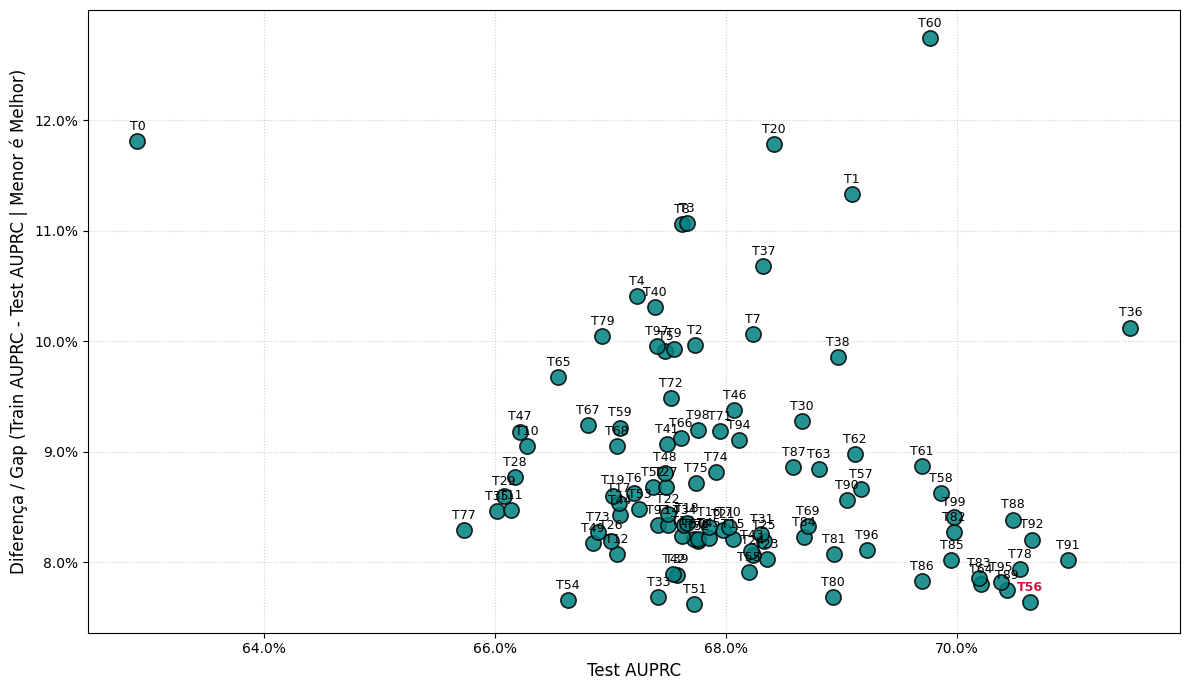

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix

# ==========================================
# 1. SALVAR OS MELHORES PARÂMETROS E TREINAR
# ==========================================

# Pegar o melhor trial do Optuna (já considerando a penalização do gap)
best_trial = study_top15.best_trial
best_params = best_trial.params

print("--- MELHORES HIPERPARÂMETROS ENCONTRADOS ---")
for k, v in best_params.items():
    print(f"{k}: {v}")

# Adicionar parâmetros fixos que não foram variados no Optuna
best_params['scale_pos_weight'] = ratio
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['n_jobs'] = -1

# Instanciar e treinar o Modelo Final com as 15 Variáveis
final_model = XGBClassifier(**best_params)
final_model.fit(X_train_top15, y_train)

# Avaliação Final no Conjunto de Teste
y_pred_proba = final_model.predict_proba(X_test_top15)[:, 1]
final_auprc = average_precision_score(y_test, y_pred_proba)

print(f"\nAUPRC do Modelo Final (15 Variáveis): {final_auprc*100:.2f}%")


# ==========================================
# 2. GRÁFICO DE ANÁLISE DOS TRIALS (SCATTER PLOT)
# ==========================================

# Filtrar o DataFrame de resultados para o gráfico
top_n_results_optuna_df = results_optuna_df_sorted.copy()

plt.figure(figsize=(12, 7))

# Mapeamento com os nomes exatos das colunas numéricas calculadas no Optuna
scatter = plt.scatter(
    top_n_results_optuna_df['test_pr_auc_num'], 
    top_n_results_optuna_df['gap_num'], 
    color='teal', 
    s=120, 
    edgecolors='black', 
    linewidth=1.2,
    alpha=0.85,
    zorder=3
)

plt.xlabel('Test AUPRC', fontsize=12)
plt.ylabel('Diferença / Gap (Train AUPRC - Test AUPRC | Menor é Melhor)', fontsize=12)
# plt.title(f'Top {len(top_n_results_optuna_df)} Trials XGBoost (15 Variáveis): Test AUPRC vs. Overfitting Gap', fontsize=13, fontweight='bold')

# Adicionar os IDs dos trials acima de cada ponto
for index, row in top_n_results_optuna_df.iterrows():
    # Destacar o melhor trial com a cor vermelha no texto
    is_best = (row['trial_number'] == best_trial.number)
    txt_color = 'crimson' if is_best else 'black'
    
    plt.annotate(
        f"T{row['trial_number']}",
        (row['test_pr_auc_num'], row['gap_num']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        fontweight='bold' if is_best else 'normal',
        color=txt_color
    )

# Formatação dos eixos em porcentagem para facilitar a leitura
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))

plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

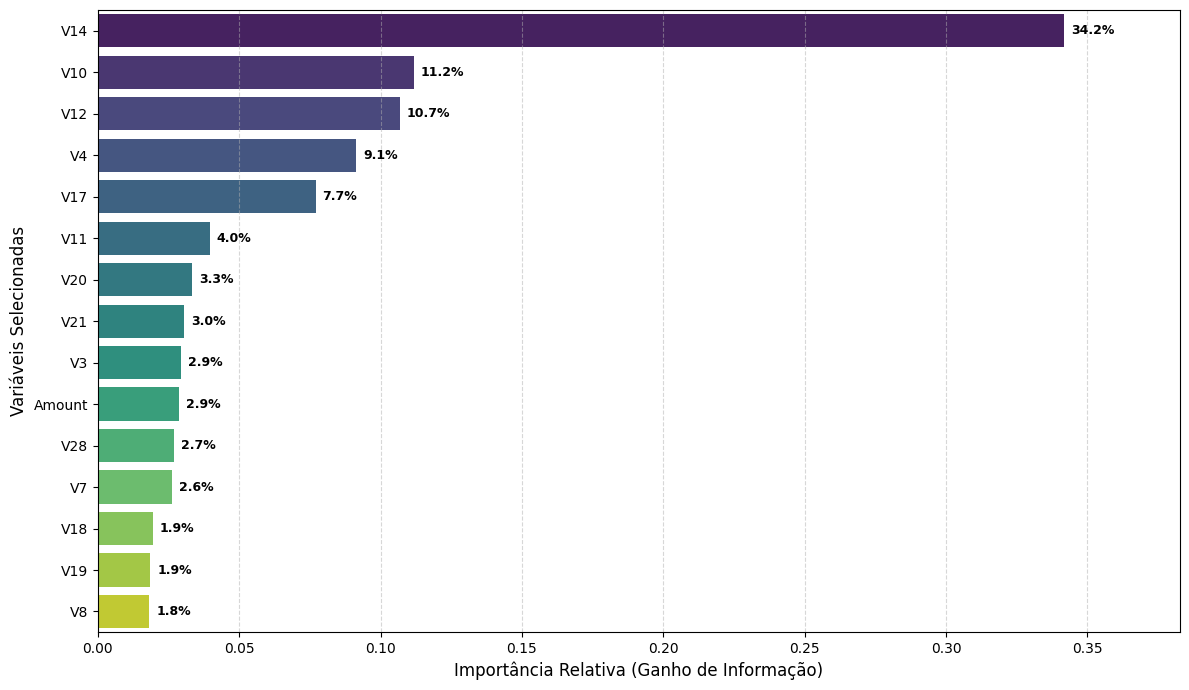

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extrair a importância das variáveis do modelo treinado de produção
importances_production = final_model.feature_importances_

# 2. Criar DataFrame ordenado para o gráfico
prod_importance_df = pd.DataFrame({
    'Variável': top_15_features,
    'Importância': importances_production
}).sort_values(by='Importância', ascending=False).reset_index(drop=True)

# 3. Gerar a visualização gráfica
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Importância',
    y='Variável',
    data=prod_importance_df,
    palette='viridis',
    hue='Variável',
    legend=False
)

# Adicionar o valor numérico (porcentagem de importância) em cada barra
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width*100:.1f}%",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

# plt.title('Importância das 15 Variáveis no Modelo XGBoost de Produção (Trial 56)', fontsize=14, fontweight='bold')
plt.xlabel('Importância Relativa (Ganho de Informação)', fontsize=12)
plt.ylabel('Variáveis Selecionadas', fontsize=12)

# Expandir o limite do eixo X para dar espaço aos rótulos percentuais
plt.xlim(0, max(prod_importance_df['Importância']) * 1.12)

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

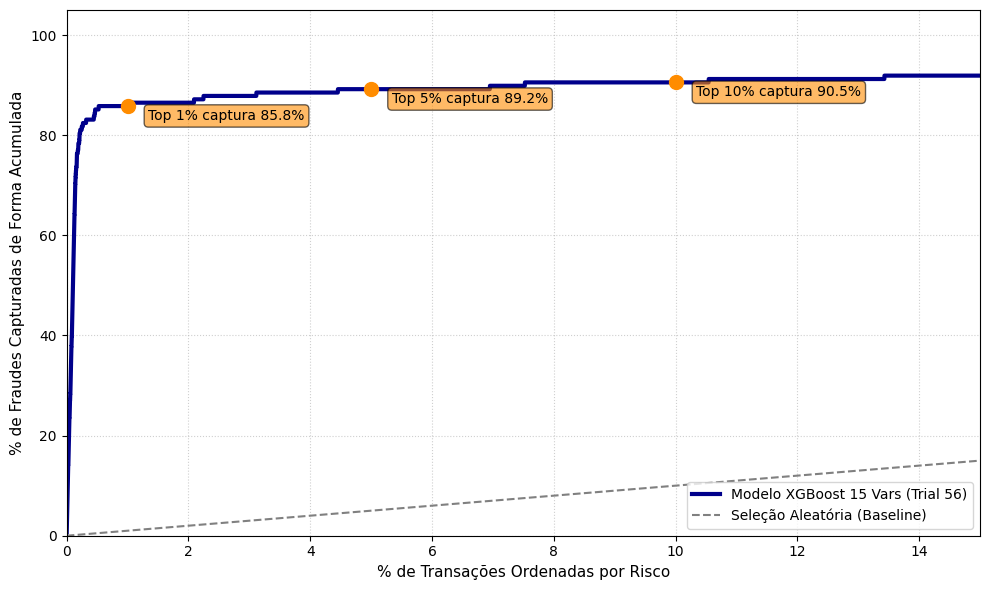

--- EFICIÊNCIA OPERACIONAL DE CAPTURA DE FRAUDE (TRIAL 56) ---
Ao analisar apenas o Top 1% das transações mais suspeitas, o modelo captura 85.81% de TODAS as fraudes.
Ao analisar apenas o Top 5% das transações mais suspeitas, o modelo captura 89.19% de TODAS as fraudes.
Ao analisar apenas o Top 10% das transações mais suspeitas, o modelo captura 90.54% de TODAS as fraudes.


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. ESCORAGEM DO MODELO DE 15 VARIÁVEIS (TRIAL 56)
# ==============================================================================
# Gerar probabilidades no conjunto de teste com as 15 variáveis selecioandas
y_pred_proba_15 = final_model.predict_proba(X_test_top15)[:, 1]

# Criar DataFrame com as pontuações e valores reais, ordenando por Risco (Descendente)
df_scores = pd.DataFrame({
    'Probabilidade_Risco': y_pred_proba_15,
    'Real': y_test
}).sort_values(by='Probabilidade_Risco', ascending=False).reset_index(drop=True)

# Parâmetros gerais de contagem
total_transacoes = len(df_scores)
total_fraudes = df_scores['Real'].sum()
percentuais = [0.01, 0.05, 0.10] # Top 1%, 5% e 10%

# ==============================================================================
# 2. CÁLCULO DA CURVA DE GANHO CUMULATIVO
# ==============================================================================
df_scores['Fraudes_Acumuladas'] = df_scores['Real'].cumsum()
df_scores['Percentual_Fraudes_Capturadas'] = (df_scores['Fraudes_Acumuladas'] / total_fraudes) * 100
df_scores['Percentual_Base_Ordenada'] = (df_scores.index + 1) / total_transacoes * 100

# ==============================================================================
# 3. GERAR O GRÁFICO (CUMULATIVE GAINS CURVE)
# ==============================================================================
plt.figure(figsize=(10, 6))

plt.plot(
    df_scores['Percentual_Base_Ordenada'], 
    df_scores['Percentual_Fraudes_Capturadas'], 
    color='darkblue', 
    linewidth=3, 
    label='Modelo XGBoost 15 Vars (Trial 56)'
)

plt.plot([0, 100], [0, 100], color='gray', linestyle='--', label='Seleção Aleatória (Baseline)')

# Marcar os pontos estratégicos de corte (1%, 5% e 10%)
for p in percentuais:
    idx_p = int(total_transacoes * p) - 1
    pct_base = df_scores.loc[idx_p, 'Percentual_Base_Ordenada']
    pct_captura = df_scores.loc[idx_p, 'Percentual_Fraudes_Capturadas']

    plt.scatter(pct_base, pct_captura, color='darkorange', s=100, zorder=5)
    plt.annotate(
        f"Top {p*100:.0f}% captura {pct_captura:.1f}%",
        (pct_base, pct_captura),
        textcoords="offset points",
        xytext=(15, -10),
        ha='left',
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="darkorange", alpha=0.6)
    )

# plt.title('Curva de Ganho Cumulativo: Concentração de Fraudes no Topo da Fila (15 Vars)', fontsize=13, fontweight='bold')
plt.xlabel('% de Transações Ordenadas por Risco', fontsize=11)
plt.ylabel('% de Fraudes Capturadas de Forma Acumulada', fontsize=11)

# Foco no topo da lista (primeiros 15% das transações mais suspeitas)
plt.xlim(0, 15)  
plt.ylim(0, 105)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# Print executivo com o resumo numérico
print("--- EFICIÊNCIA OPERACIONAL DE CAPTURA DE FRAUDE (TRIAL 56) ---")
for p in percentuais:
    idx_p = int(total_transacoes * p) - 1
    pct_captura = df_scores.loc[idx_p, 'Percentual_Fraudes_Capturadas']
    print(f"Ao analisar apenas o Top {p*100:.0f}% das transações mais suspeitas, o modelo captura {pct_captura:.2f}% de TODAS as fraudes.")